# Vegetation Manhour Model — Evaluation Pipeline 

## 1. Imports & Configuration

In [1]:
import os
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    confusion_matrix,
    median_absolute_error
)
from sklearn.inspection import permutation_importance
from scipy.stats import bootstrap

from catboost import CatBoostRegressor, Pool
import lightgbm as lgb
from xgboost import XGBRegressor

try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    HAS_OPTUNA = True
except ImportError:
    HAS_OPTUNA = False

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
CONFIG = {
    "input_dir": "../input_data",
    "output_dir": "./deployment",
    # Feeder-level over/under tolerance band
    "feeder_tolerance_pct": 0.15,  # +/-15% counted as "within tolerance"
    # Workload tier thresholds on ACTUAL manhours (hours).
    "tier_labels": ["Light", "Light-Medium","Medium-Heavy", "Heavy"],
}


os.makedirs(CONFIG["output_dir"], exist_ok=True)
CONFIG


{'input_dir': '../input_data',
 'output_dir': './deployment',
 'feeder_tolerance_pct': 0.15,
 'tier_labels': ['Light', 'Light-Medium', 'Medium-Heavy', 'Heavy']}

## 2. Load & Clean Data

Loads the span-level dataset, deduplicates repeated `bay` records, joins in span/circuit
attributes, and merges pole-level accessibility predictions.


In [3]:
df = pd.read_csv(os.path.join(CONFIG["input_dir"], "bay_clean_data.csv"))


# Duplicate bays: sum numeric fields, concatenate text fields, keep first bay_* field
nonunique_bays = df["bay"].value_counts()[lambda x: x > 1].index
print(f"Duplicate bay records found: {len(nonunique_bays)}")




Duplicate bay records found: 36


In [4]:
df["index_within_group"] = df.groupby("bay").cumcount() + 1
df["bay_unique"] = df.apply(
    lambda row: row["bay"] * 100 + row["index_within_group"] if row["bay"] in nonunique_bays else row["bay"],
    axis=1
)


# Add duplicate flag (only for duplicates)
df["duplicate"] = df["bay"].apply(lambda x: 1 if x in nonunique_bays else 0)

# Drop helper column used for suffixing
df = df.drop(columns=["index_within_group"])

print(f"Spans: {df.shape[0]:,}")

# Recode work type: Lift-related = 1, Unavailable = 0, No Lift Access = 2
df["bay_worktype_n"] = df["bay_work_type"].apply(
    lambda x: 0 if "Unavailable" in x else (2 if "No Lift Access" in x else 1)
)

Spans: 24,284


In [5]:
# number of records by vendor & percentage
vendor_counts = df['vendor'].value_counts()
vendor_percentage = df['vendor'].value_counts(normalize=True) * 100
vendor_counts, vendor_percentage

(vendor
 ATE       18022
 Intren     6262
 Name: count, dtype: int64,
 vendor
 ATE       74.213474
 Intren    25.786526
 Name: proportion, dtype: float64)

In [6]:
# Convert 'complete_date' to datetime, handling missing or invalid entries
# Preserve the original values
df["complete_date_raw"] = df["complete_date"].copy()

# Parse both:
# YYYY-MM-DD
# YYYY-MM-DD HH:MM:SS
df["complete_date"] = pd.to_datetime(
    df["complete_date_raw"],
    format="mixed",
    errors="coerce"
)


# Truncate to date (YYYY-MM-DD format)
df['date_only'] = df['complete_date'].dt.date

# Count unique days
unique_days = df['date_only'].dropna().unique()

# Display unique days
print(f"Number of unique days: {len(unique_days)}")

Number of unique days: 134


In [7]:
# manhours to equal crew size * completion hours
df['manhours']= df['total_crew_hrs']

In [8]:
# Join span/circuit aggregate attributes
agg_data = pd.read_csv(os.path.join(CONFIG["input_dir"], "bay_span_agg_data.csv"))
#agg_data.set_index("bay", inplace=True)

append_cols = ["truck_access", "num_circuits", "num_conductors", "num_phases_cegis", "aerial_cable","bay"]
#existing_append_cols = [c for c in append_cols if c in df.columns]
#if existing_append_cols:
    #df = df.drop(columns=existing_append_cols)

# join with df on the "bay" column
df = df.merge(agg_data[append_cols], on="bay", how="left")


truck_map = {"yes": 1, "y": 1, "true": 1, "1": 1, "no": 0, "n": 0, "false": 0, "0": 0}
df["truck_access"] = (
    df["truck_access"].astype(str).str.strip().str.lower().map(truck_map).fillna(-1).astype(int)
)
for col in ["num_circuits", "num_conductors", "num_phases_cegis", "aerial_cable"]:
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(-1)

df[["truck_access", "num_circuits", "num_conductors", "num_phases_cegis", "aerial_cable"]].describe(include="all")


,truck_access,num_circuits,num_conductors,num_phases_cegis,aerial_cable
count,24284.000000,24284.000000,24284.000000,24284.000000,24284.000000
mean,0.522484,1.298221,2.375885,2.087012,-0.001565
std,0.501643,1.027166,1.502252,0.980289,0.074269
min,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,0.000000,1.000000,1.000000,1.000000,0.000000
50%,1.000000,1.000000,3.000000,3.000000,0.000000
75%,1.000000,1.000000,3.000000,3.000000,0.000000
max,1.000000,9.000000,10.000000,3.000000,1.000000


In [9]:
agg_data[append_cols].head(10)

,truck_access,num_circuits,num_conductors,num_phases_cegis,aerial_cable,bay
0,True,1,2,2,0,14745278
1,True,1,2,2,0,14745279
2,True,1,2,2,0,14745280
3,True,1,2,2,0,14745281
4,True,1,2,2,0,14745282
5,True,1,3,3,0,14745283
6,True,1,3,3,0,14745284
7,True,1,1,1,0,14745285
8,True,1,3,3,0,14745286
9,True,1,3,3,0,14745287


In [10]:
# Merge pole-level accessibility classifier predictions onto spans (both endpoint poles)
accessibility_file = os.path.join(CONFIG["input_dir"], "Matteo_model_all_images_predictions_with_railroads.csv")
required_access_cols = {"pole_number", "output", "has_railroad"}

access_data = pd.read_csv(accessibility_file)
missing_access_cols = sorted(required_access_cols.difference(access_data.columns))
if missing_access_cols:
    raise ValueError(f"Missing required accessibility columns: {missing_access_cols}")

access_data = access_data.copy()
access_data["client_pole_id"] = access_data["pole_number"].astype(str).str.strip()
access_data["inaccessible_flag"] = access_data["output"].astype(str).str.strip().eq("3")
access_data["railroad_flag"] = access_data["has_railroad"].fillna(0).astype(int).eq(1)

access_lookup = (
    access_data[["client_pole_id", "inaccessible_flag", "railroad_flag"]]
    .drop_duplicates(subset=["client_pole_id"], keep="last")
    .reset_index(drop=True)
)
print(f"Accessibility rows loaded: {len(access_lookup):,}")

pole1_col, pole2_col = "bay_client_pole1_id", "bay_client_pole2_id"
for required_col in [pole1_col, pole2_col]:
    if required_col not in df.columns:
        raise ValueError(f"Expected column not found: {required_col}")
df[pole1_col] = df[pole1_col].astype(str).str.strip()
df[pole2_col] = df[pole2_col].astype(str).str.strip()

drop_if_exists = ["inaccessible_pole1", "railroad_pole1", "inaccessible_pole2", "railroad_pole2"]
df = df.drop(columns=[c for c in drop_if_exists if c in df.columns])

access_p1 = access_lookup.rename(columns={
    "client_pole_id": pole1_col, "inaccessible_flag": "inaccessible_pole1", "railroad_flag": "railroad_pole1"
})
access_p2 = access_lookup.rename(columns={
    "client_pole_id": pole2_col, "inaccessible_flag": "inaccessible_pole2", "railroad_flag": "railroad_pole2"
})

df = df.reset_index()
df = df.merge(access_p1[[pole1_col, "inaccessible_pole1", "railroad_pole1"]], on=pole1_col, how="left")
df = df.merge(access_p2[[pole2_col, "inaccessible_pole2", "railroad_pole2"]], on=pole2_col, how="left")

# A span is inaccessible/railroad-adjacent if EITHER endpoint pole is flagged
df['access_missing_both_poles'] = (
    df['inaccessible_pole1'].isna() & df['inaccessible_pole2'].isna()
)
df["inaccessible_raw"] = (
    df["inaccessible_pole1"].fillna(True) | df["inaccessible_pole2"].fillna(True)
).astype(int)
df["railroad_span"] = (
    df["railroad_pole1"].fillna(True) | df["railroad_pole2"].fillna(True)
).astype(int)

# fill missing values for inaccessible with truck access
df['inaccessible'] = df['inaccessible_raw']
df['truck_inaccess_bool'] = np.nan
#df['truck_access_tier'] = np.nan
if 'truck_access' in df.columns:
    df['truck_inaccess_bool'] = df['truck_access'].map(lambda x: np.nan if pd.isna(x) else not bool(x))
    #df['truck_access_tier'] = np.where(
        #df['truck_access_bool'].eq(True),
        #'Accessible',
        #np.where(df['truck_access_bool'].eq(False), 'Constrained', np.nan),
    #)

df['accessibility_fill_from_truck_access'] = False
unknown_mask = df['access_missing_both_poles'].eq(True)
fill_mask = unknown_mask & df['truck_inaccess_bool'].notna()
# turn to 0 and 1 for truck_inaccess_bool to match inaccessible column
df['truck_inaccess_bool'] = df['truck_inaccess_bool'].astype(int)
df.loc[fill_mask, 'inaccessible'] = df.loc[fill_mask, 'truck_inaccess_bool']
df.loc[fill_mask, 'accessibility_fill_from_truck_access'] = True

print("Mean manhours by accessibility:")
print(df.groupby("inaccessible")["manhours"].mean())
print(df.groupby("railroad_span")["manhours"].mean())



Accessibility rows loaded: 1,302,425
Mean manhours by accessibility:
inaccessible
0    3.154935
1    5.493508
Name: manhours, dtype: float64
railroad_span
0    4.159766
1    4.290963
Name: manhours, dtype: float64


In [11]:
# lift vs non-lift work type: mean manhours
print("Mean manhours by lift vs non-lift work type:")
print(df.groupby("lift")["manhours"].mean())

Mean manhours by lift vs non-lift work type:
lift
0    5.833814
1    3.105928
Name: manhours, dtype: float64


In [12]:
# count and % of spans inaccessible
inaccessible_spans_count = df[df['inaccessible'] == True].shape[0]
inaccessible_spans_percentage = (inaccessible_spans_count / df.shape[0]) * 100
print(f"Inaccessible spans count: {inaccessible_spans_count}")
print(f"Inaccessible spans percentage: {inaccessible_spans_percentage:.2f}%")

Inaccessible spans count: 10647
Inaccessible spans percentage: 43.84%


In [13]:
# count and % of spans railroad_span
railroad_span_count = df[df['railroad_span'] == True].shape[0]
railroad_span_percentage = (railroad_span_count / df.shape[0]) * 100
print(f"Railroad spans count: {railroad_span_count}")
print(f"Railroad spans percentage: {railroad_span_percentage:.2f}%")

Railroad spans count: 3780
Railroad spans percentage: 15.57%


In [14]:
# join to get geometry from bay_data.csv
bay_geometry = pd.read_csv(os.path.join(CONFIG["input_dir"], "bay_data.csv"))
# join metric_df with bay_geometry on "bay" column
#df = df.merge(bay_geometry, on="bay", how="left")

# keep only bay_geometry columns
#bay_geometry.columns.tolist()
#df = df[bay_geometry.columns.tolist()]

# convert to csv and save to output_dir
#df.to_csv(os.path.join(CONFIG["output_dir"], "bay_geometry.csv"), index=False)

## 3. Feature Engineering

In [15]:
def engineer_features(frame: pd.DataFrame) -> pd.DataFrame:
    """Roll raw severity-color intrusion volumes/counts into heavy/moderate/low
    contact bands, plus derived ratios used across the modeling pipeline."""
    frame = frame.copy()

    frame["heavy_contact_vol"] = frame["bay_red_volume_(cubic_ft)"] + frame["bay_orange_volume_(cubic_ft)"]
    frame["heavy_contact_count"] = frame["bay_red_count"] + frame["bay_orange_count"]
    frame["heavy_contact_flag"] = (frame["heavy_contact_vol"] > 0).astype(int)

    frame["moderate_contact_vol"] = frame["bay_yellow_volume_(cubic_ft)"] + frame["bay_green_volume_(cubic_ft)"]
    frame["moderate_contact_count"] = frame["bay_yellow_count"] + frame["bay_green_count"]
    frame["moderate_contact_flag"] = (frame["moderate_contact_vol"] > 0).astype(int)

    frame["low_contact_vol"] = frame["bay_blue_volume_(cubic_ft)"]
    frame["low_contact_count"] = frame["bay_blue_count"]
    frame["low_contact_flag"] = (frame["low_contact_vol"] > 0).astype(int)

    frame["side_intrusion_vol"] = (
        frame["bay_total_intrusion_volume_(cubic_ft)"]
        #- frame["bay_oh_volume_(cubic_ft)"]
        - frame["bay_os_volume_(cubic_ft)"]
        #- frame["bay_ug_volume_(cubic_ft)"]
        - frame["bay_purple_volume_(cubic_ft)"]
    ).clip(lower=0)

    eps = 1e-6
    frame["heavy_contact_ratio"] = frame["heavy_contact_vol"] / (frame["bay_total_intrusion_volume_(cubic_ft)"] + eps)
    frame["moder_contact_ratio"] = frame["moderate_contact_vol"] / (frame["bay_total_intrusion_volume_(cubic_ft)"] + eps)
    frame["low_contact_ratio"] = frame["low_contact_vol"] / (frame["bay_total_intrusion_volume_(cubic_ft)"] + eps)
    frame["trim_vol_by_span"]= frame["side_intrusion_vol"]*frame["bay_total_span_length_(ft)"]
    frame["heavy_contact_cond"] = frame["heavy_contact_vol"]/(frame["num_conductors"]+eps)
    frame["trim_vol_by_length"]= (frame["side_intrusion_vol"]/(frame["bay_length_(ft)"]+eps))*frame["bay_total_span_length_(ft)"]
    frame["intrusion_per_ft"] = frame["bay_total_intrusion_volume_(cubic_ft)"] / (frame["bay_length_(ft)"] + eps)
    frame["heavy_lin_to_ttl_lin"] = (
        frame.get("bay_l&r_red_(ft)", 0).fillna(0) + frame.get("bay_l&r_orange_(ft)", 0).fillna(0) + frame.get("bay_l&r_yellow_(ft)", 0).fillna(0) + frame.get("bay_l&r_green_(ft)", 0).fillna(0) 
    ) / (frame["bay_length_(ft)"] + eps)
    #frame["area_to_length"] = frame.get("est_area", np.nan) / (frame["bay_length_(ft)"] + eps)

    #frame["access_terrain_interaction"] = (frame["inaccessible"]) * frame["bay_total_intrusion_volume_(cubic_ft)"]
    #frame["access_complex_l&r"]=(frame["inaccessible"]) * frame["bay_l&r_purple_ft"]
    #frame["access_complex_lvl"]=frame["inaccessible"]* (frame["bay_lvl_purple_(ft)"] + frame["bay_lvl_blue_(ft)"])
    frame["railroad_terrain_interaction"] = frame["railroad_span"] * frame["bay_total_intrusion_volume_(cubic_ft)"]
    
    return frame


target = "manhours"
raw_feature_candidates = [
    col for col in df.columns
    if col.startswith("bay_")
    and df[col].dtype in ["int64", "float64"]
    and col not in ["bay_site1_id", "bay_site2_id", "bay_publication_id", "bay_ma_number", "bay_unique"] # bay_worktype_n
]

df[target] = df[target].fillna(-1)
df[raw_feature_candidates] = df[raw_feature_candidates].fillna(0)
df = engineer_features(df)

engineered_features = [
    "side_intrusion_vol", "heavy_contact_vol", "heavy_contact_count", "heavy_contact_flag",
    "heavy_contact_ratio", "low_contact_vol", "moderate_contact_vol", "low_contact_count",
    "moderate_contact_count", "low_contact_flag", "moderate_contact_flag", "avg_stem_size",
    "intrusion_per_ft", "overhang_flag", "undergrowth_intensity", "max_voltage_kV",
    "num_circuits", "num_conductors", "min_distance_to_ccl","railroad",
    "num_phases_cegis", "heavy_lin_to_ttl_lin", "moder_contact_ratio", "low_contact_ratio",
    "access_terrain_interaction", "access_complex_l&r", "access_complex_lvl", "railroad_terrain_interaction",
    "trim_vol_by_span", "trim_vol_by_length", "heavy_contact_cond", #"heavy_contact_conductors"
    #"area_to_length", "est_area",
     "inaccessible",  # intentionally left out of the default feature set here.
    #                    It's introduced on its own, later, for the dedicated
    #                    with/without comparison in Section 9 — see that section
    #                    for why it isn't just folded in upstream.
]
engineered_features = [c for c in engineered_features if c in df.columns]
feature_cols = engineered_features + raw_feature_candidates
feature_cols = sorted(set(feature_cols))
print(f"Candidate features: {len(feature_cols)}")


Candidate features: 59


In [16]:
# Threshold exploration for bottom/top 20-25% manhours:
# 1) all spans, 2) inaccessible only, 3) accessible only
required_cols = ["manhours", "inaccessible"]
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise RuntimeError(f"Missing required columns in df: {missing_cols}")

tmp = df[required_cols].copy()
tmp["manhours"] = pd.to_numeric(tmp["manhours"], errors="coerce")
tmp = tmp.dropna(subset=["manhours"])

def _to_bool_inaccessible(v):
    if pd.isna(v):
        return np.nan
    if isinstance(v, (bool, np.bool_)):
        return bool(v)
    if isinstance(v, (int, float, np.integer, np.floating)):
        if v in (0, 1):
            return bool(int(v))
        return np.nan
    if isinstance(v, str):
        s = v.strip().lower()
        if s in {"1", "true", "t", "yes", "y", "inaccessible"}:
            return True
        if s in {"0", "false", "f", "no", "n", "accessible"}:
            return False
    return np.nan

tmp["inaccessible_bool"] = tmp["inaccessible"].map(_to_bool_inaccessible).astype("boolean")

def _threshold_stats(series, label):
    s = pd.to_numeric(series, errors="coerce").dropna()
    if s.empty:
        return pd.Series({
            "dataset": label,
            "n": 0,
            "q20_bottom": np.nan,
            "q25_bottom": np.nan,
            "q50_bottom": np.nan,
            "q50_top": np.nan,
            "q75_top": np.nan,
            "q80_top": np.nan,
            "bottom_20pct_actual": np.nan,
            "bottom_25pct_actual": np.nan,
            "top_20pct_actual": np.nan,
            "top_25pct_actual": np.nan,
            "low_threshold_suggested_min": np.nan,
            "low_threshold_suggested_max": np.nan,
            "high_threshold_suggested_min": np.nan,
            "high_threshold_suggested_max": np.nan,
        })

    q20 = s.quantile(0.20)
    q25 = s.quantile(0.25)
    q75 = s.quantile(0.75)
    q80 = s.quantile(0.80)

    return pd.Series({
        "dataset": label,
        "n": int(s.shape[0]),
        "q20_bottom": float(q20),
        "q25_bottom": float(q25),
        "q40_bottom": float(s.quantile(0.40)),
        "q50_bottom": float(s.quantile(0.50)),
        "q60_top": float(s.quantile(0.60)),
        "q75_top": float(q75),
        "q80_top": float(q80),
        "bottom_20pct_actual": float((s <= q20).mean()),
        "bottom_25pct_actual": float((s <= q25).mean()),
        "bottom_40pct_actual": float((s <= s.quantile(0.40)).mean()),
        "bottom_50pct_actual": float((s <= s.quantile(0.50)).mean()),
        "top_20pct_actual": float((s >= q80).mean()),
        "top_25pct_actual": float((s >= q75).mean()),
        "top_40pct_actual": float((s >= s.quantile(0.60)).mean()),
        "low_threshold_suggested_min": float(q20),
        "low_threshold_suggested_max": float(q25),
        "high_threshold_suggested_min": float(q75),
        "high_threshold_suggested_max": float(q80),
    })

stats_all = _threshold_stats(tmp["manhours"], "all_spans")
stats_inacc = _threshold_stats(
    tmp.loc[tmp["inaccessible_bool"] == True, "manhours"],
    "inaccessible_spans"
 )
stats_acc = _threshold_stats(
    tmp.loc[tmp["inaccessible_bool"] == False, "manhours"],
    "accessible_spans"
 )

threshold_summary = pd.DataFrame([stats_all, stats_inacc, stats_acc])

pct_cols = ["bottom_20pct_actual", "bottom_25pct_actual", "top_20pct_actual", "top_25pct_actual"]
threshold_summary[pct_cols] = threshold_summary[pct_cols] * 100.0

display_cols = [
    "dataset", "n",
    "q20_bottom", "q25_bottom", "q40_bottom", "q50_bottom",
    "q60_top", "q75_top", "q80_top",
    "bottom_20pct_actual", "bottom_25pct_actual", "bottom_40pct_actual",
    "top_20pct_actual", "top_25pct_actual", "top_40pct_actual", "bottom_50pct_actual",
    "low_threshold_suggested_min", "low_threshold_suggested_max",
    "high_threshold_suggested_min", "high_threshold_suggested_max",
]

print("Candidate threshold ranges to capture about 20-25% tails:")
print("- Bottom threshold candidates: between q20 and q25")
print("- Top threshold candidates: between q75 and q80")
display(threshold_summary[display_cols].round(3))

Candidate threshold ranges to capture about 20-25% tails:
- Bottom threshold candidates: between q20 and q25
- Top threshold candidates: between q75 and q80


,dataset,n,q20_bottom,q25_bottom,q40_bottom,q50_bottom,q60_top,q75_top,q80_top,bottom_20pct_actual,bottom_25pct_actual,bottom_40pct_actual,top_20pct_actual,top_25pct_actual,top_40pct_actual,bottom_50pct_actual,low_threshold_suggested_min,low_threshold_suggested_max,high_threshold_suggested_min,high_threshold_suggested_max
0,all_spans,24284,2.0,2.0,2.0,3.0,4.0,6.0,6.0,43.778,43.778,0.438,25.412,25.412,0.464,0.535,2.0,2.0,6.0,6.0
1,inaccessible_spans,10647,2.0,2.0,4.0,4.0,6.0,8.0,8.0,28.928,28.928,0.549,28.722,28.722,0.414,0.549,2.0,2.0,8.0,8.0
2,accessible_spans,13637,2.0,2.0,2.0,2.0,3.0,4.0,4.0,55.371,55.371,0.554,33.248,33.248,0.444,0.554,2.0,2.0,4.0,4.0


In [17]:
inacces_thres = [2.5,4.5,7]
access_thres = [2,3,4]

In [18]:
# percent of spans < 3 
access_df = df[df['inaccessible']==0]
print("Percent of access spans < 3")
print(access_df[access_df['manhours'] < 2].shape[0] / access_df.shape[0] * 100)

# percent of span > 5
print("Percent of access spans > 5")
print(access_df[access_df['manhours'] > 4].shape[0] / access_df.shape[0] * 100)

print("Percent of access spans equal to 2")
print(access_df[access_df['manhours'] == 2].shape[0] / access_df.shape[0] * 100)

inaccess_df = df[df['inaccessible']==1]

# percent of spans < 3 for inaccessible spans
print("Percent of inaccessible spans < 3")
print(inaccess_df[inaccess_df['manhours'] < 5].shape[0] / inaccess_df.shape[0] * 100)

# percent of spans > 5 for inaccessible spans
print("Percent of inaccessible spans > 5")
print(inaccess_df[inaccess_df['manhours'] > 8].shape[0] / inaccess_df.shape[0] * 100)

Percent of access spans < 3
17.467184864706315
Percent of access spans > 5
15.523942216029917
Percent of access spans equal to 2
37.90423113588032
Percent of inaccessible spans < 3
56.60749506903353
Percent of inaccessible spans > 5
16.65257819103973


In [19]:
# percent of spans with impactful issue
print("Percent of spans with impactful issue:")
print(df['impactful_issues'].notna().sum() / len(df) * 100)

Percent of spans with impactful issue:
24.345247899851756


### Non-vegetation / vegetation operations snapshot (condensed)

Retained as quick context, not a modeling input change: non-vegetation spans are a small
share of both records and total hours, and are flagged (`nonveg_span`) rather than dropped,
per the open question on whether they should be modeled separately.


In [20]:
nonveg_mask = (
    df["bay_total_intrusion_volume_(cubic_ft)"].isna()
    | (df["bay_total_intrusion_volume_(cubic_ft)"] == 0)
)
df["nonveg_span"] = nonveg_mask.astype(int)

summary = {
    "Total Spans": len(df),
    "Distinct Feeders": df["feeder"].nunique(),
    "Total Manhours": round(df["manhours"].sum(), 1),
    "Mean Manhours": round(df["manhours"].mean(), 2),
    "Non-Veg Spans": int(nonveg_mask.sum()),
    "Non-Veg % of Spans": round(nonveg_mask.mean() * 100, 1),
    "Non-Veg % of Hours": round(df.loc[nonveg_mask, "manhours"].sum() / df["manhours"].sum() * 100, 1),
}
for k, v in summary.items():
    print(f"{k:24}{v}")


Total Spans             24284
Distinct Feeders        433
Total Manhours          101496.1
Mean Manhours           4.18
Non-Veg Spans           882
Non-Veg % of Spans      3.6
Non-Veg % of Hours      2.3


In [21]:
# no-veg spans
#drop index column from df
df=df.drop(columns=["index"])
no_veg_spans = df[df["nonveg_span"] == True]
display(no_veg_spans.head(15).sort_values(by="manhours", ascending=False))

,bay,work_region,feeder,site_id,remote_id,comments,site_last_changed_on,complete_date,site_last_changed_by,crew_leader,...,heavy_contact_ratio,moder_contact_ratio,low_contact_ratio,trim_vol_by_span,heavy_contact_cond,trim_vol_by_length,intrusion_per_ft,heavy_lin_to_ttl_lin,railroad_terrain_interaction,nonveg_span
33,15228760,SOUTH,F525,7501713.0,SpanReport20260117_104453,NaN,"5/12/2026, 1:35:40 PM",2026-05-12,Jesus Sanchez,Jesus Sanchez,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
223,14764235,WEST,"B961, L12371",7525051.0,SpanReport20260117_17294,Not enough time,"6/9/2026, 11:07:22 AM",2026-02-04,Ryan Solomon,Jason Gilbert,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
499,15128189,WEST,B303,7564320.0,SpanReport20260117_91233,NaN,"4/20/2026, 1:04:26 PM",2026-04-20,James Benson,James Benson,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
197,15081744,NaN,J661,7712870.0,SpanReport20260203_2608,NaN,"4/16/2026, 11:01:28 AM",2026-03-05,Ryan Solomon,Victor Leanos,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
87,15330755,NaN,J661,7708699.0,SpanReport20260203_15362,NaN,"2/10/2026, 2:12:32 PM",2026-02-10,Victor Leanos,Victor Leanos,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
780,15273911,SOUTH,F5283,7496548.0,SpanReport20260117_105863,NaN,"4/20/2026, 10:42:44 AM",2026-04-18,Julio Sanchez,Julio Sanchez,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
1604,15133901,WEST,B303,7566094.0,SpanReport20260117_96406,Heavy training,"3/26/2026, 2:50:04 PM",2026-03-26,Jose Perez Hernandez,Ruben Vasquez,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
190,14752655,WEST,E196,7514896.0,SpanReport20260117_6296,NaN,"2/27/2026, 12:23:33 PM",2026-02-13,Alberto Ocampo,Carlos Hernandez,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
1038,14812299,NW,R6401Y,7546573.0,SpanReport20260117_49454,NaN,"2/16/2026, 2:23:23 PM",2026-02-10,Ramiro Delgado,Aaron Figueroa,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
1173,15137987,WEST,B375,7594805.0,SpanReport20260117_99312,NaN,"6/24/2026, 11:48:31 AM",2026-06-24,James Benson,James Benson,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1


In [22]:
# Data quality
manhour_validation = pd.Series(np.asarray(df['manhours']))
print(f"Unique values in manhour_validation: {manhour_validation.nunique()} out of {len(manhour_validation)}")
print("\nCommon actual manhours:")
print(manhour_validation.value_counts().sort_index().head(65))

Unique values in manhour_validation: 112 out of 24284

Common actual manhours:
-1.00     3
 0.00    57
 0.03     1
 0.06     5
 0.09     1
         ..
 6.25     1
 6.30     1
 6.50     2
 6.60     1
 7.00    85
Name: count, Length: 65, dtype: int64


In [23]:
# drop null manhours
df = df[df['manhours'] != -1]

In [24]:
# Lidar Metric subgroup
# include data with impactful_issues
metric_df = df[df["impactful_issues"].notna()]

# append non-veg
metric_df = pd.concat([metric_df, df[df["nonveg_span"] == True]])

columns_to_keep = ["feeder","vendor","total_crew_hrs","equipment_types","impactful_issues", "nonveg_span"]

# anything beginning with "bay"
columns_to_keep += [col for col in df.columns if col.startswith("bay")]

metric_df = metric_df[columns_to_keep].copy()
bay_geometry = bay_geometry[["bay","Site1 Lati","Site1 Long","Site2 Lati","Site2 Long","geometry"]].copy()

# join metric_df with bay_geometry on "bay" column
metric_df = metric_df.merge(bay_geometry, on="bay", how="left")

# convert to csv and save to output_dir
metric_df.to_csv(os.path.join(CONFIG["output_dir"], "metric_df.csv"), index=False)

In [25]:
# create bins for heavy_lin_to_ttl_lin 
n_bins=4
col_min= df["heavy_lin_to_ttl_lin"].min()
col_max= df["heavy_lin_to_ttl_lin"].max()
bin_edges=np.linspace(col_min,col_max,n_bins+1)
labels= [1,2,3,4]
df["heavy_lin_to_ttl_lin_bin"] = pd.cut(df["heavy_lin_to_ttl_lin"], bins=bin_edges, labels=labels, include_lowest=True)

# determine the mean manhours per bin 
mean_manhours_per_bin = df.groupby("heavy_lin_to_ttl_lin_bin")["manhours"].mean()
print(mean_manhours_per_bin)

# save records that are outliers based on 

mean_manhours_per_bin_lin_inaccessible = df.groupby(["heavy_lin_to_ttl_lin_bin", "inaccessible"])["manhours"].mean()
print(mean_manhours_per_bin_lin_inaccessible)

heavy_lin_to_ttl_lin_bin
1    3.461113
2    5.990282
3    6.926806
4    7.937938
Name: manhours, dtype: float64
heavy_lin_to_ttl_lin_bin  inaccessible
1                         0               2.835000
                          1               4.532541
2                         0               4.580967
                          1               6.868551
3                         0               5.564827
                          1               7.479736
4                         0               6.239726
                          1               8.611685
Name: manhours, dtype: float64


In [26]:
# create bins for side_intrusion_vol
n_bins=4
col_min= df["side_intrusion_vol"].min()
col_max= df["side_intrusion_vol"].max()
bin_edges=np.linspace(col_min,col_max,n_bins+1)
labels= [1,2,3,4]
df["side_intrusion_vol_bin"] = pd.cut(df["side_intrusion_vol"], bins=bin_edges, labels=labels, include_lowest=True) 

# manhours per bin for trim_vol_by_length_bin and inaccessible
mean_manhours_per_bin_side_intrusion = df.groupby("side_intrusion_vol_bin")["manhours"].mean()
print(mean_manhours_per_bin_side_intrusion)

mean_manhours_per_bin_side_intrusion_inaccessible = df.groupby(["side_intrusion_vol_bin", "inaccessible"])["manhours"].mean()
print(mean_manhours_per_bin_side_intrusion_inaccessible)

side_intrusion_vol_bin
1    4.113508
2    7.783565
3    6.990909
4    6.000000
Name: manhours, dtype: float64
side_intrusion_vol_bin  inaccessible
1                       0               3.097553
                        1               5.424127
2                       0               6.837940
                        1               8.591202
3                       0               7.500000
                        1               5.633333
4                       0               6.000000
                        1                    NaN
Name: manhours, dtype: float64


In [27]:
# create bins for total trims
df["total_veg_work"]= df["total_trims"] + df["total_removals"]+ df["brush_removals"]+ df["brush_trims"]
n_bins=4
col_min= df["total_veg_work"].min()
col_max= df["total_veg_work"].max()
bin_edges=np.linspace(col_min,col_max,n_bins+1)
labels= [1,2,3,4]
df["total_veg_work_bin"] = pd.cut(df["total_veg_work"], bins=bin_edges, labels=labels, include_lowest=True)

# manhours per bin for total_veg_work_bin and inaccessible
mean_manhours_per_bin_total_veg_work = df.groupby("total_veg_work_bin")["manhours"].mean()
print(mean_manhours_per_bin_total_veg_work) 

mean_manhours_per_bin_total_veg_work_inaccessible = df.groupby(["total_veg_work_bin", "inaccessible"])["manhours"].mean()
print(mean_manhours_per_bin_total_veg_work_inaccessible)

total_veg_work_bin
1     3.983098
2     8.829751
3     9.548828
4    12.094872
Name: manhours, dtype: float64
total_veg_work_bin  inaccessible
1                   0                3.057303
                    1                5.204276
2                   0                6.667715
                    1               10.246095
3                   0                6.385417
                    1               11.446875
4                   0                9.409091
                    1               13.150000
Name: manhours, dtype: float64


In [28]:
veg_mask = (
    (df["total_veg_work"].isna()) |
    (df["total_veg_work"] == 0)
)


# veg tier
df.loc[~veg_mask, "veg_tier"] = pd.qcut(
    df.loc[~veg_mask, "total_veg_work"],
    q=[0, 0.25, 0.75, 1.00],
    labels=[
        "Light",
        "Medium",
        "Heavy"
    ]
).astype(str)

# mean manhours per veg_tier and inaccessible
mean_manhours_per_veg_tier = df.groupby("veg_tier")["manhours"].mean()
print(mean_manhours_per_veg_tier)   

mean_manhours_per_veg_tier_inaccessible = df.groupby(["veg_tier", "inaccessible"])["manhours"].mean()
print(mean_manhours_per_veg_tier_inaccessible)

veg_tier
Heavy     6.935690
Light     2.239055
Medium    4.298936
Name: manhours, dtype: float64
veg_tier  inaccessible
Heavy     0               5.505113
          1               7.935169
Light     0               2.027778
          1               2.795767
Medium    0               3.478746
          1               5.131080
Name: manhours, dtype: float64


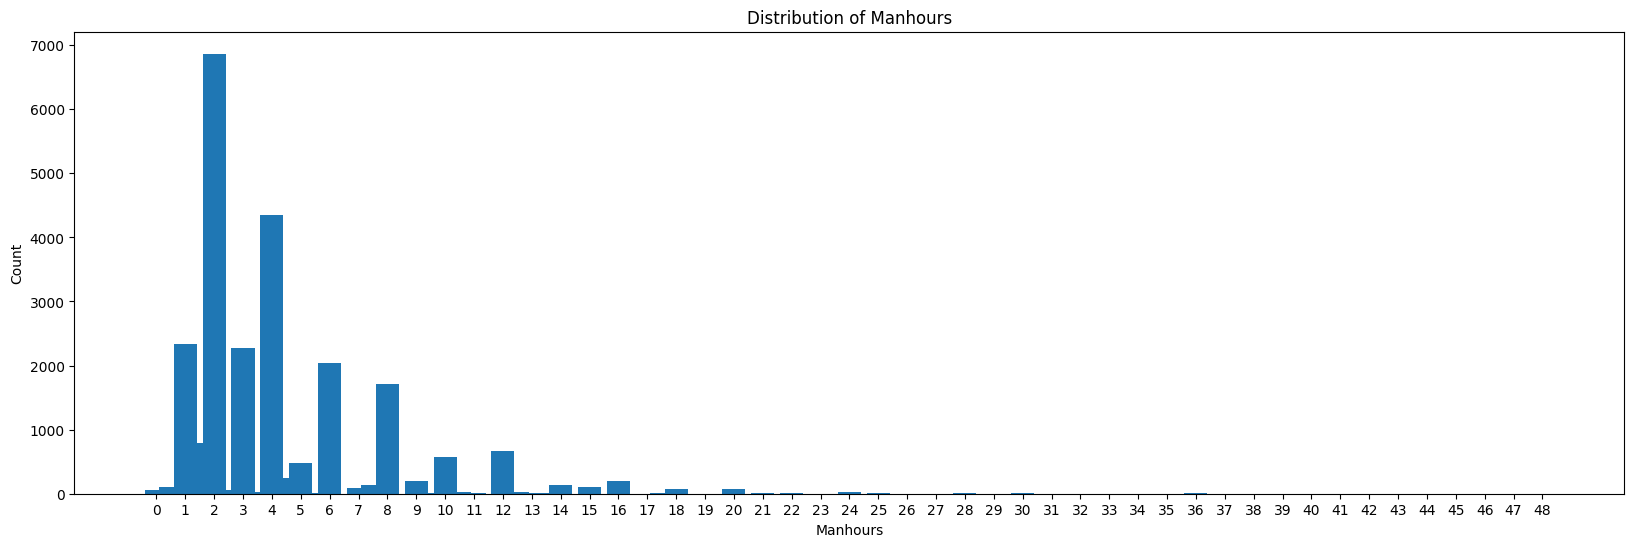

In [29]:
# show count of records per each manhour value as distribution chart, including the range, add value count label
manhour_counts = df["manhours"].value_counts().sort_index()
plt.figure(figsize=(20, 6))
plt.bar(manhour_counts.index, manhour_counts.values)
# include more x-ticks for better visibility
plt.xticks(np.arange(0, manhour_counts.index.max() + 1, 1))
# add value count label on top of each bar
plt.xlabel("Manhours")
plt.ylabel("Count")
plt.title("Distribution of Manhours")
plt.show()

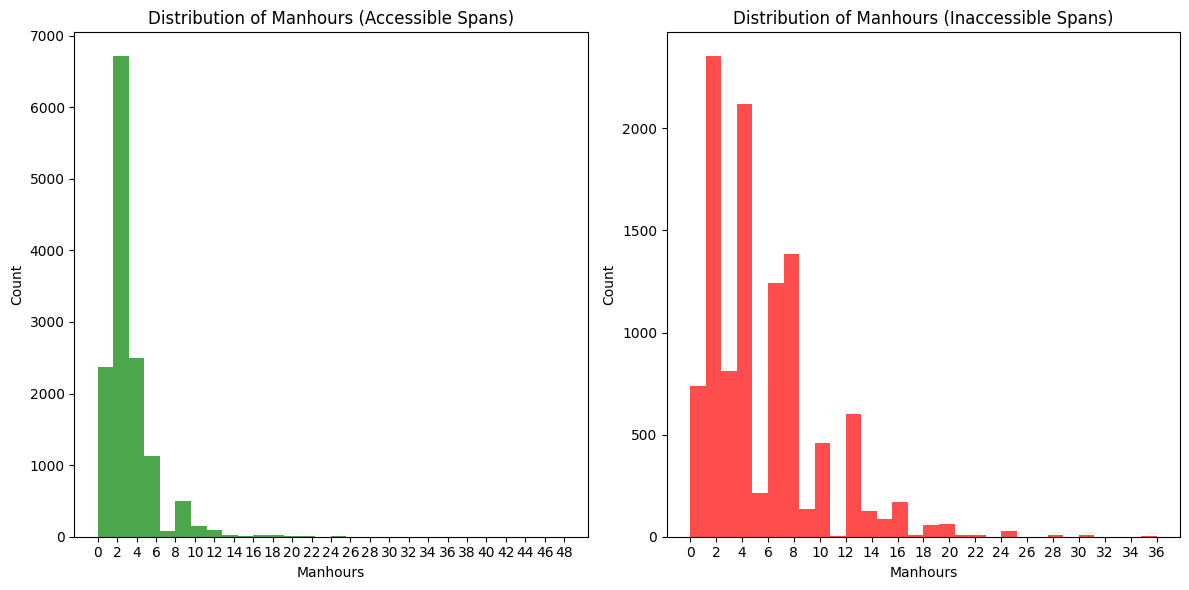

Accessible Manhours Range: (0.0, 48.0)
Inaccessible Manhours Range: (0.0, 36.0)


In [30]:
# two chart side by side of distribution of manhours (accessible vs inaccessible)
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
accessible_manhours = df[df["inaccessible"] == 0]["manhours"]
plt.hist(accessible_manhours, bins=30, color='green', alpha=0.7)
plt.xticks(np.arange(0, accessible_manhours.max() + 1, 2))
plt.xlabel("Manhours")
plt.ylabel("Count")
plt.title("Distribution of Manhours (Accessible Spans)")

plt.subplot(1, 2, 2)
inaccessible_manhours = df[df["inaccessible"] == 1]["manhours"]
plt.hist(inaccessible_manhours, bins=30, color='red', alpha=0.7)
plt.xticks(np.arange(0, inaccessible_manhours.max() + 1, 2))
plt.xlabel("Manhours")
plt.ylabel("Count")
plt.title("Distribution of Manhours (Inaccessible Spans)")

plt.tight_layout()
plt.show()

# print range for both accessible and inaccessible manhours
accessible_range = (accessible_manhours.min(), accessible_manhours.max())
inaccessible_range = (inaccessible_manhours.min(), inaccessible_manhours.max())
print(f"Accessible Manhours Range: {accessible_range}")
print(f"Inaccessible Manhours Range: {inaccessible_range}")

In [31]:
# avg manhours by impactful_issues column, include null values in the groupby
avg_manhours_by_issue = df.groupby("impactful_issues", dropna=False)["manhours"].mean().sort_values(ascending=False)

print(avg_manhours_by_issue)

impactful_issues
Heavy Contact      7.754179
Long Brush Drag    5.589891
Weather            5.553593
Access Issues      4.366816
Infrastructure     4.054237
Busy Area          4.002198
NaN                3.916265
Other              3.886667
Flagging           3.683591
Name: manhours, dtype: float64


In [32]:
# % of spans by impactful issue including na
print("Percent of spans by impactful issue:")
print(df['impactful_issues'].value_counts(dropna=False, normalize=True) * 100)

Percent of spans by impactful issue:
impactful_issues
NaN                75.655863
Long Brush Drag     8.315144
Flagging            5.321033
Access Issues       3.673654
Heavy Contact       2.808781
Busy Area           1.873893
Other               1.420864
Weather             0.687781
Infrastructure      0.242988
Name: proportion, dtype: float64


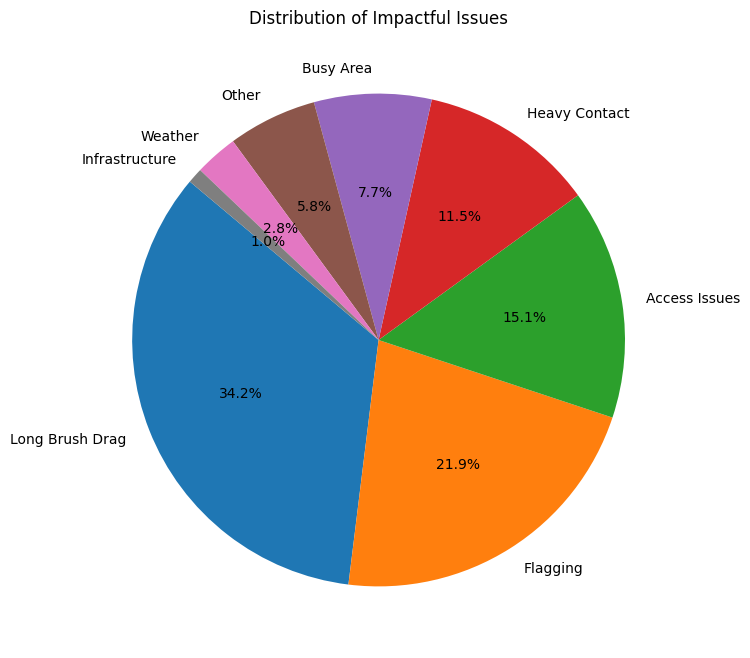

In [33]:
# pie chart of impactful_issues 
impactful_issues_counts = df["impactful_issues"].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(impactful_issues_counts, labels=impactful_issues_counts.index, autopct='%1.1f%%', startangle=140)
plt.title("Distribution of Impactful Issues")
plt.show()

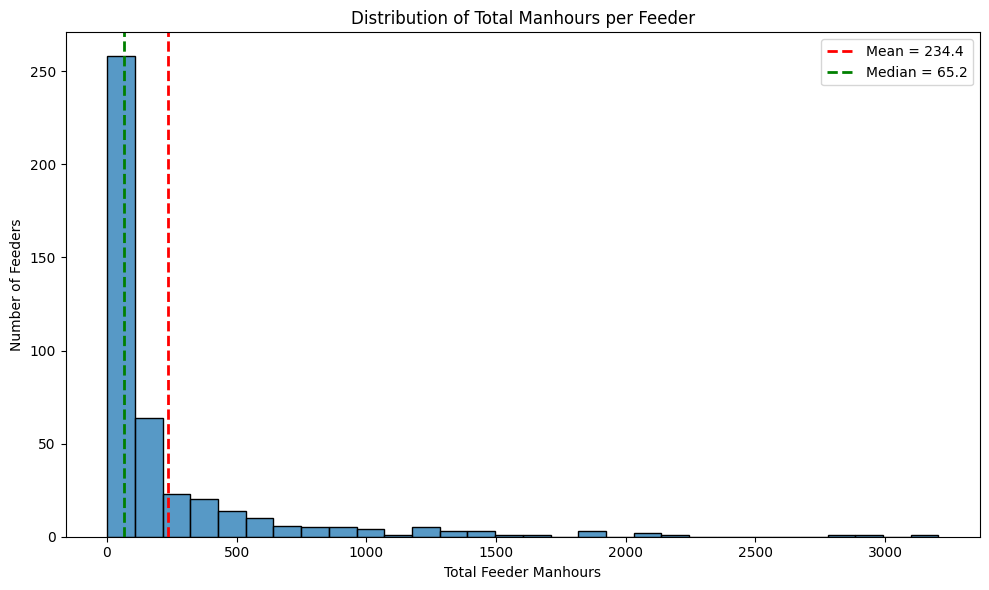

In [34]:
# Aggregate span-level data to feeder-level
feeder_summary = (
    df.groupby('feeder')
      .agg(
          total_manhours=('manhours', 'sum'),
          span_count=('bay', 'count')
      )
      .reset_index()
)

plt.figure(figsize=(10, 6))

sns.histplot(
    feeder_summary['total_manhours'],
    bins=30,
    color='#1f77b4',
    edgecolor='black'
)

plt.axvline(
    feeder_summary['total_manhours'].mean(),
    color='red',
    linestyle='--',
    linewidth=2,
    label=f"Mean = {feeder_summary['total_manhours'].mean():.1f}"
)

plt.axvline(
    feeder_summary['total_manhours'].median(),
    color='green',
    linestyle='--',
    linewidth=2,
    label=f"Median = {feeder_summary['total_manhours'].median():.1f}"
)

plt.title('Distribution of Total Manhours per Feeder')
plt.xlabel('Total Feeder Manhours')
plt.ylabel('Number of Feeders')
plt.legend()

plt.tight_layout()
plt.show()

In [35]:
def bootstrap_ci(series,
                 confidence_level=0.95,
                 n_resamples=5000,
                 random_state=42):
    
    values = series.dropna().values
    
    if len(values) < 2:
        return pd.Series({
            "ci_lower": np.nan,
            "ci_upper": np.nan
        })
    
    result = bootstrap(
        (values,),
        np.mean,
        confidence_level=confidence_level,
        n_resamples=n_resamples,
        random_state=random_state,
        method="percentile"
    )
    
    return pd.Series({
        "ci_lower": result.confidence_interval.low,
        "ci_upper": result.confidence_interval.high
    })

In [36]:
# exclude non-veg spans from the segment summary
df_tier = df[df["veg_tier"] != "No Veg"].copy()
segment_summary = (
    df_tier.groupby(["inaccessible", "veg_tier"])
      .apply(
          lambda x: pd.Series({
              "count": len(x),
              "mean": x["manhours"].mean(),
              "median": x["manhours"].median(),
              "std": x["manhours"].std(),
              "min": x["manhours"].min(),
              "max": x["manhours"].max(),
              
              # Typical observed range
              "p10": x["manhours"].quantile(0.10),
              "p90": x["manhours"].quantile(0.90),

              # Bootstrapped confidence interval
              "mean_ci_lower":
                  bootstrap_ci(x["manhours"])["ci_lower"],

              "mean_ci_upper":
                  bootstrap_ci(x["manhours"])["ci_upper"],
          })
      )
      .reset_index()
)

segment_summary

,inaccessible,veg_tier,count,mean,median,std,min,max,p10,p90,mean_ci_lower,mean_ci_upper
0,0,Heavy,2337.0,5.505113,4.0,3.869285,0.5,48.0,2.0,10.0,5.348074,5.668443
1,0,Light,6237.0,2.027778,2.0,1.074392,0.0,12.0,1.0,3.0,2.001723,2.055109
2,0,Medium,4943.0,3.478746,3.0,2.052081,0.0,21.0,2.0,6.0,3.423540,3.536758
3,1,Heavy,3345.0,7.935169,8.0,4.914876,0.0,36.0,2.0,15.0,7.770581,8.103777
4,1,Light,2367.0,2.795767,2.0,1.863685,0.0,14.0,1.0,5.0,2.721939,2.869432
5,1,Medium,4872.0,5.131080,4.0,3.438011,0.0,30.0,1.5,10.0,5.036623,5.230851


In [37]:
# remove No Veg from df
df = df[df["nonveg_span"] == 0]

Original feature count: 59
Reduced feature count (PCA): 20


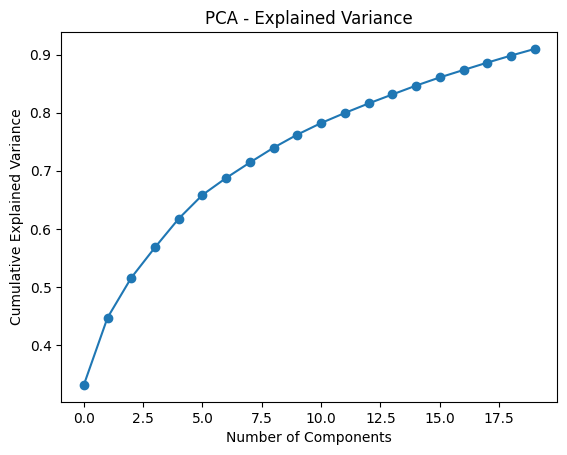

In [38]:
# Apply PCA for clustering
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df[feature_cols])
df_features = df_scaled

from sklearn.decomposition import PCA

# Retain components that explain 90% of the variance
pca = PCA(n_components=0.90)  # Adjust n_components to retain desired variance
df_pca = pca.fit_transform(df_features)

print("Original feature count:", df_features.shape[1])
print("Reduced feature count (PCA):", df_pca.shape[1])

# Plot explained variance ratio
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker="o")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA - Explained Variance")
plt.show()

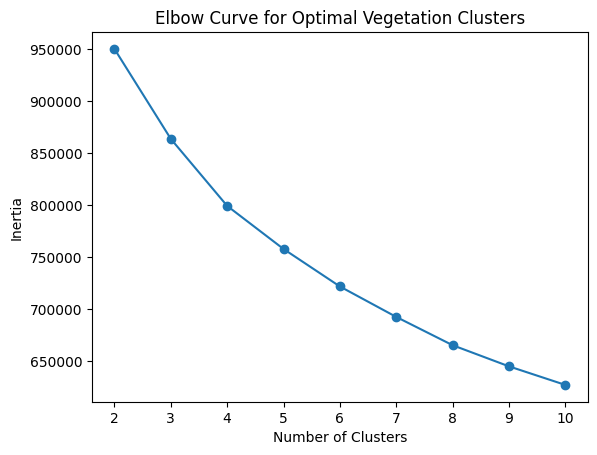

In [39]:
from sklearn.cluster import KMeans

inertia = []

# Test k values from 2 to 10
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_pca)
    inertia.append(kmeans.inertia_)

# Plot elbow curve
plt.plot(range(2, 11), inertia, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Curve for Optimal Vegetation Clusters")
plt.show()

In [40]:
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
df["vegetation_tier_kmeans"] = kmeans.fit_predict(df_scaled)

In [41]:
from sklearn.cluster import AgglomerativeClustering

agg_clustering = AgglomerativeClustering(n_clusters=4, linkage="ward")
df["veg_tier_hierarchical"] = agg_clustering.fit_predict(df_pca)

In [42]:
# group manhours by kmean tier, calculating mean, median, mode, stdev, min and max
from scipy import stats

grouped = df.groupby("vegetation_tier_kmeans")["manhours"]
kmean_summary = grouped.agg([
    pd.Series.mean, 
    pd.Series.median, 
    lambda x: float(stats.mode(x, keepdims=True).mode[0]),  # Ensure scalar value for mode
    pd.Series.std, 
    pd.Series.min, 
    pd.Series.max
])
kmean_summary.rename(columns={"<lambda>": "mode"}, inplace=True)  # Correct name for lambda column
kmean_summary

,mean,median,<lambda_0>,std,min,max
vegetation_tier_kmeans,,,,,,
0,2.683383,2.0,2.0,2.030091,0.0,30.0
1,4.777964,4.0,4.0,3.477783,0.0,48.0
2,4.871871,4.0,4.0,3.706585,0.0,36.0
3,7.127868,6.0,4.0,4.802686,0.0,36.0


In [43]:
grouped = df.groupby("veg_tier_hierarchical")["manhours"]
hierarchical_summary = grouped.agg([
    pd.Series.mean, 
    pd.Series.median, 
    lambda x: float(stats.mode(x, keepdims=True).mode[0]),  # Ensure scalar value for mode
    pd.Series.std, 
    pd.Series.min, 
    pd.Series.max
])
hierarchical_summary.rename(columns={"<lambda>": "mode"}, inplace=True)  # Correct name for lambda column
hierarchical_summary

,mean,median,<lambda_0>,std,min,max
veg_tier_hierarchical,,,,,,
0,4.598921,4.0,2.0,3.497773,0.0,48.0
1,7.003358,6.0,4.0,4.772016,0.0,36.0
2,2.700431,2.0,2.0,2.101191,0.0,30.0
3,3.849316,3.0,2.0,3.311310,0.0,36.0


In [44]:
# add tiers to feature_cols
feature_cols.extend(["vegetation_tier_kmeans", "veg_tier_hierarchical"])

segment_order = [
    "Accessible No Veg",
    "Accessible Light",
    "Accessible Medium",
    "Accessible Heavy",
    "Inaccessible No Veg",
    "Inaccessible Light",
    "Inaccessible Medium",
    "Inaccessible Heavy",
]

segment_summary["segment"] = pd.Categorical(
    segment_summary["segment"],
    categories=segment_order,
    ordered=True
)

display(
    segment_summary[
        [
            "segment",
            "count",
            "summary",
            "typical_range"
        ]
    ]
    .sort_values("segment")
)


## 4. Feeder-Grouped Train / Test / Validation / Holdout Split

Splitting is done on **unique feeders**, not spans, so no feeder appears in more than one
split (prevents leakage). Roles, per the reorganized pipeline:

| Split | Used for |
|---|---|
| **Train** | Fitting every candidate model |
| **Test** | Stage 1 |
| **Validation** | Stage 2  (span-level *and* feeder-level) |
| **Holdout** | Untouched. Reserved for a final pre-deployment check only |




In [45]:
# Feeder-grouped splits, with reuse of saved artifacts.
#
# Saved splits in SPLIT_DIR are loaded instead of recomputed unless FORCE_RESPLIT
# is True. Recomputing writes the artifacts back out, so the two paths stay in sync.

FORCE_RESPLIT = False # True = always recompute, ignoring anything already saved

RANDOM_STATE = 42
HOLDOUT_TARGET_SHARE = 0.20

# Allow a feeder-based holdout as low as ~17% before expanding the recent-month window.
HOLDOUT_SHARE_TOLERANCE = 0.03

# Remaining development feeders: 70% train, 15% validation, 15% test.
DEV_TEMP_SHARE = 0.30

MIN_HOLDOUT_SPANS = 500
MIN_HOLDOUT_FEEDERS = 20

SPLIT_NAMES = ["train", "test", "valid", "holdout"]
SPLIT_DIR = os.path.join(CONFIG["output_dir"], "splits")
os.makedirs(SPLIT_DIR, exist_ok=True)


def split_artifact_path(split_name, part):
    return os.path.join(SPLIT_DIR, f"{part}_{split_name}.csv")


saved_split_paths = {
    split_name: {part: split_artifact_path(split_name, part) for part in ["X", "y", "meta"]}
    for split_name in SPLIT_NAMES
}

saved_splits_available = all(
    os.path.exists(path)
    for split_paths in saved_split_paths.values()
    for path in split_paths.values()
)


def save_splits(splits_to_save):
    for split_name, split_data in splits_to_save.items():
        split_data["X"].to_csv(saved_split_paths[split_name]["X"], index=True)
        split_data["y"].to_frame(target).to_csv(saved_split_paths[split_name]["y"], index=True)
        split_data["meta"].to_csv(saved_split_paths[split_name]["meta"], index=True)

    print(f"Saved train/test/valid/holdout artifacts to {SPLIT_DIR}")


def load_splits():
    loaded = {}

    for split_name in SPLIT_NAMES:
        X_split = pd.read_csv(saved_split_paths[split_name]["X"], index_col=0)
        y_split = pd.read_csv(saved_split_paths[split_name]["y"], index_col=0)[target]
        meta_split = pd.read_csv(saved_split_paths[split_name]["meta"], index_col=0)

        for frame in [X_split, y_split, meta_split]:
            frame.index = frame.index.astype(df.index.dtype)
            frame.index.name = "bay_unique"

        meta_split["date_only"] = pd.to_datetime(meta_split["date_only"], errors="coerce")

        loaded[split_name] = {"X": X_split, "y": y_split.astype(float), "meta": meta_split}

    return loaded


if not FORCE_RESPLIT and saved_splits_available:
    splits = load_splits()

    feature_cols = splits["train"]["X"].columns.tolist()

    print(f"Loaded saved splits from {SPLIT_DIR} (set FORCE_RESPLIT=True to recompute).")

else:
    if "df" not in globals() or "feature_cols" not in globals() or "target" not in globals():
        raise ValueError(
            "Missing required variables. Run the data preparation and "
            "feature-engineering cells first."
        )

    missing_columns = {"feeder", "date_only", target}.difference(df.columns)
    if missing_columns:
        raise KeyError(f"Missing required dataframe columns: {sorted(missing_columns)}")

    if df.index.name != "bay_unique":
        if "bay_unique" in df.columns:
            df = df.set_index("bay_unique", drop=False)
        else:
            raise ValueError("Expected bay_unique index (or bay_unique column to set index).")

    if not FORCE_RESPLIT and saved_splits_available:
        splits = load_splits()


    missing_features = [col for col in feature_cols if col not in df.columns]
    if missing_features:
        raise KeyError(f"The following feature columns are missing from df: {missing_features}")

    # --------------------------------------------------------
    # Work on a copy and validate the bay_unique index
    # --------------------------------------------------------

    split_df = df.copy()
    split_df.index.name = "bay_unique"
    original_record_count = len(split_df)

    if split_df.index.isna().any():
        raise ValueError(
            f"The bay_unique index contains {split_df.index.isna().sum():,} missing values."
        )

    if split_df.index.duplicated().any():
        raise ValueError(
            f"The bay_unique index contains {int(split_df.index.duplicated().sum()):,} duplicates."
        )

    split_df["date_only"] = pd.to_datetime(
        split_df["date_only"], format="mixed", errors="coerce"
    ).dt.normalize()

    if split_df["date_only"].notna().sum() == 0:
        raise ValueError("No valid values remain in date_only after conversion.")

    # --------------------------------------------------------
    # Remove records without feeder identifiers
    # --------------------------------------------------------

    missing_feeder_mask = split_df["feeder"].isna()
    missing_feeder_count = int(missing_feeder_mask.sum())
    missing_feeder_df = split_df.loc[missing_feeder_mask].copy()
    split_df = split_df.loc[~missing_feeder_mask].copy()

    print(
        f"Removed {missing_feeder_count:,} records with missing feeders "
        f"({missing_feeder_count / original_record_count:.2%})."
    )
    print(f"Remaining records available for splitting: {len(split_df):,}")

    split_df["missing_complete_date_flag"] = split_df["date_only"].isna().astype(int)

    # --------------------------------------------------------
    # Recent month windows
    # --------------------------------------------------------

    latest_date = split_df["date_only"].max()
    latest_month_start = latest_date.to_period("M").start_time

    window_options = [
        {"months": 1, "label": "Latest calendar month", "start_date": latest_month_start},
        {
            "months": 2,
            "label": "Latest two calendar months",
            "start_date": latest_month_start - pd.DateOffset(months=1),
        },
        {
            "months": 3,
            "label": "Latest three calendar months",
            "start_date": latest_month_start - pd.DateOffset(months=3),
        },
    ]

    print(f"\nLatest valid date: {latest_date.date()}")
    for window in window_options:
        print(
            f"{window['months']}-month candidate window: "
            f"{window['start_date'].date()} through {latest_date.date()}"
        )

    # --------------------------------------------------------
    # Preferred holdout size
    # --------------------------------------------------------

    total_span_count = len(split_df)
    target_holdout_spans = int(round(total_span_count * HOLDOUT_TARGET_SHARE))

    minimum_acceptable_holdout_spans = max(
        MIN_HOLDOUT_SPANS,
        int(round(total_span_count * (HOLDOUT_TARGET_SHARE - HOLDOUT_SHARE_TOLERANCE))),
    )

    print(f"\nTotal spans: {total_span_count:,}")
    print(f"Preferred holdout: {target_holdout_spans:,} spans ({HOLDOUT_TARGET_SHARE:.0%})")
    print(f"Minimum acceptable holdout: {minimum_acceptable_holdout_spans:,} spans")

    # --------------------------------------------------------
    # Feeder-level summary
    # --------------------------------------------------------

    feeder_span_counts = (
        split_df.groupby("feeder").size().rename("feeder_spans").reset_index()
    )

    feeder_date_summary = split_df.groupby("feeder", as_index=False).agg(
        dated_spans=("date_only", lambda series: series.notna().sum()),
        missing_date_spans=("date_only", lambda series: series.isna().sum()),
        feeder_first_date=("date_only", "min"),
        feeder_last_date=("date_only", "max"),
    )

    feeder_summary = feeder_span_counts.merge(feeder_date_summary, on="feeder", how="left")
    feeder_summary["all_dates_available"] = feeder_summary["missing_date_spans"].eq(0)
    feeder_summary["date_completeness_pct"] = (
        feeder_summary["dated_spans"] / feeder_summary["feeder_spans"]
    )
    feeder_summary["feeder_observed_days"] = (
        feeder_summary["feeder_last_date"] - feeder_summary["feeder_first_date"]
    ).dt.days.add(1)

    print("\nFeeder-level date quality:")
    print("Feeders with complete dates:", int(feeder_summary["all_dates_available"].sum()))
    print(
        "Feeders with at least one missing date:",
        int((~feeder_summary["all_dates_available"]).sum()),
    )
    display(feeder_summary.head())

    # Eligible holdout feeders must have complete dates and an entire record
    # history inside the requested recent window.
    def get_fully_recent_feeders(feeder_level_summary, window_start, window_end):
        eligible_feeders = feeder_level_summary.loc[
            feeder_level_summary["all_dates_available"]
            & feeder_level_summary["feeder_first_date"].ge(window_start)
            & feeder_level_summary["feeder_last_date"].le(window_end)
        ].copy()

        return (
            eligible_feeders.sort_values(
                ["feeder_spans", "feeder_last_date", "feeder_first_date", "feeder"],
                ascending=[False, False, False, True],
            )
            .reset_index(drop=True)
        )

    def select_feeders_near_target(eligible_feeders, target_span_count):
        if eligible_feeders.empty:
            return np.array([], dtype=object)

        cumulative_spans = np.cumsum(eligible_feeders["feeder_spans"].to_numpy())
        closest_position = int(np.argmin(np.abs(cumulative_spans - target_span_count)))

        return eligible_feeders.loc[:closest_position, "feeder"].to_numpy()

    def summarize_holdout_candidate(data, selected_feeders):
        candidate_data = data.loc[data["feeder"].isin(selected_feeders)]

        if candidate_data.empty:
            return {
                "spans": 0, "feeders": 0, "share": 0.0,
                "missing_dates": 0, "first_date": pd.NaT, "last_date": pd.NaT,
            }

        return {
            "spans": len(candidate_data),
            "feeders": candidate_data["feeder"].nunique(),
            "share": len(candidate_data) / len(data),
            "missing_dates": int(candidate_data["date_only"].isna().sum()),
            "first_date": candidate_data["date_only"].min(),
            "last_date": candidate_data["date_only"].max(),
        }

    # --------------------------------------------------------
    # Try latest 1 month, then 2 months, then 3 months
    # --------------------------------------------------------

    selected_holdout_feeders = None
    selected_window = None
    window_candidate_results = []

    for window in window_options:
        eligible_feeders = get_fully_recent_feeders(
            feeder_summary, window["start_date"], latest_date
        )
        candidate_feeders = select_feeders_near_target(eligible_feeders, target_holdout_spans)
        candidate_summary = summarize_holdout_candidate(split_df, candidate_feeders)
        eligible_span_count = int(eligible_feeders["feeder_spans"].sum())

        window_candidate_results.append({
            "window": window["label"],
            "window_start": window["start_date"],
            "eligible_feeders": len(eligible_feeders),
            "eligible_spans": eligible_span_count,
            "selected_feeders": candidate_summary["feeders"],
            "selected_spans": candidate_summary["spans"],
            "selected_share": candidate_summary["share"],
            "selected_missing_dates": candidate_summary["missing_dates"],
            "selected_first_date": candidate_summary["first_date"],
            "selected_last_date": candidate_summary["last_date"],
        })

        print(f"\n{window['label']}")
        print(f"  Fully eligible recent feeders: {len(eligible_feeders):,}")
        print(f"  Spans across eligible feeders: {eligible_span_count:,}")
        print(
            f"  Selected candidate: {candidate_summary['spans']:,} spans, "
            f"{candidate_summary['feeders']} feeders, "
            f"{candidate_summary['share']:.1%} of all spans"
        )

        candidate_is_adequate = (
            candidate_summary["spans"] >= minimum_acceptable_holdout_spans
            and candidate_summary["feeders"] >= MIN_HOLDOUT_FEEDERS
            and candidate_summary["missing_dates"] == 0
        )

        if candidate_is_adequate:
            selected_holdout_feeders = candidate_feeders
            selected_window = window
            print("  Candidate accepted.")
            break

        print("  Candidate is below the preferred minimum. Expanding to the next recent window.")

    window_candidate_summary = pd.DataFrame(window_candidate_results)

    print("\nHoldout-window candidate summary:")
    display(window_candidate_summary)

    # If three months is still smaller than preferred, take the largest feasible
    # group of eligible three-month feeders rather than relaxing date quality.
    if selected_holdout_feeders is None:
        widest_window = window_options[-1]

        eligible_three_month_feeders = get_fully_recent_feeders(
            feeder_summary, widest_window["start_date"], latest_date
        )

        if eligible_three_month_feeders.empty:
            raise ValueError(
                "No feeders have complete dates and an entire record history contained "
                "within the latest three calendar months. The requested recent "
                "feeder-based holdout cannot be created."
            )

        selected_holdout_feeders = select_feeders_near_target(
            eligible_three_month_feeders, target_holdout_spans
        )
        selected_window = widest_window

        fallback_summary = summarize_holdout_candidate(split_df, selected_holdout_feeders)

        print(
            "\nWARNING: The fully dated three-month feeder population does not meet the "
            "preferred holdout size."
        )
        print(
            "Using the largest practical feeder-based holdout that does not include feeders "
            "with missing dates or records older than the three-month window."
        )
        print(
            f"Final available candidate: {fallback_summary['spans']:,} spans, "
            f"{fallback_summary['feeders']} feeders, {fallback_summary['share']:.1%} of all spans"
        )

    feeders_holdout = np.asarray(selected_holdout_feeders)

    # --------------------------------------------------------
    # Holdout and development populations
    # --------------------------------------------------------

    holdout_mask = split_df["feeder"].isin(feeders_holdout)

    df_holdout = split_df.loc[holdout_mask].copy()
    df_development = split_df.loc[~holdout_mask].copy()

    if df_holdout.empty:
        raise ValueError("The final holdout is empty.")

    if df_development.empty:
        raise ValueError("The development dataset is empty.")

    holdout_window_start = selected_window["start_date"]

    holdout_feeder_date_check = df_holdout.groupby("feeder", as_index=False).agg(
        span_count=("date_only", "size"),
        missing_date_spans=("date_only", lambda series: series.isna().sum()),
        first_date=("date_only", "min"),
        last_date=("date_only", "max"),
    )

    invalid_holdout_feeders = holdout_feeder_date_check.loc[
        holdout_feeder_date_check["missing_date_spans"].gt(0)
        | holdout_feeder_date_check["first_date"].lt(holdout_window_start)
        | holdout_feeder_date_check["last_date"].gt(latest_date)
    ]

    if not invalid_holdout_feeders.empty:
        raise ValueError(
            "Some selected holdout feeders have missing dates or records outside the "
            "selected recent window."
        )

    if df_holdout["date_only"].isna().any():
        raise ValueError("The final holdout contains missing dates.")

    print(f"\nSelected holdout window: {selected_window['label']}")
    print(
        f"Allowed holdout date range: {holdout_window_start.date()} through {latest_date.date()}"
    )
    print(
        f"Actual holdout date range: {df_holdout['date_only'].min().date()} through "
        f"{df_holdout['date_only'].max().date()}"
    )
    print(
        f"Final holdout: {len(df_holdout):,} spans, {df_holdout['feeder'].nunique()} feeders, "
        f"{len(df_holdout) / len(split_df):.1%} of all spans"
    )

    # --------------------------------------------------------
    # Divide remaining feeders into train, validation, and test
    # --------------------------------------------------------

    development_feeders = df_development["feeder"].dropna().unique()

    if len(development_feeders) < 4:
        raise ValueError(
            "Not enough development feeders remain to create train, validation, and test splits."
        )

    feeders_train, feeders_temp = train_test_split(
        development_feeders, test_size=DEV_TEMP_SHARE, random_state=RANDOM_STATE
    )
    feeders_valid, feeders_test = train_test_split(
        feeders_temp, test_size=0.50, random_state=RANDOM_STATE
    )

    X_full = split_df[feature_cols].copy()
    y_full = split_df[target].copy()

    split_masks = {
        "train": split_df["feeder"].isin(feeders_train),
        "test": split_df["feeder"].isin(feeders_test),
        "valid": split_df["feeder"].isin(feeders_valid),
        "holdout": split_df["feeder"].isin(feeders_holdout),
    }

    # --------------------------------------------------------
    # Verify feeder exclusivity and single membership
    # --------------------------------------------------------

    split_feeder_sets = {
        split_name: set(split_df.loc[split_mask, "feeder"].unique())
        for split_name, split_mask in split_masks.items()
    }

    split_names = list(split_feeder_sets.keys())

    for i, split_a in enumerate(split_names):
        for split_b in split_names[i + 1:]:
            overlapping_feeders = split_feeder_sets[split_a] & split_feeder_sets[split_b]

            if overlapping_feeders:
                raise ValueError(
                    f"Feeder leakage detected between {split_a} and {split_b}: "
                    f"{len(overlapping_feeders)} overlapping feeders."
                )

    split_membership_count = sum(mask.astype(int) for mask in split_masks.values())

    if not split_membership_count.eq(1).all():
        raise ValueError(
            f"{int(split_membership_count.ne(1).sum()):,} rows were assigned to zero or "
            "multiple splits."
        )

    # --------------------------------------------------------
    # Metadata and final split dictionary
    # --------------------------------------------------------

    meta_columns = ["feeder", "date_only", "missing_complete_date_flag"]

    for optional_column in ["inaccessible", "veg_tier"]:
        if optional_column in split_df.columns:
            meta_columns.append(optional_column)

    splits = {
        split_name: {
            "X": X_full.loc[split_mask].copy(),
            "y": y_full.loc[split_mask].copy(),
            "meta": split_df.loc[split_mask, meta_columns].copy(),
        }
        for split_name, split_mask in split_masks.items()
    }

    save_splits(splits)

    print(
        f"\nPercent removed due to missing feeder: "
        f"{100 * missing_feeder_count / (len(split_df) + missing_feeder_count):.2f}%"
    )


# ------------------------------------------------------------
# Summaries and direct variables used by later cells (both paths)
# ------------------------------------------------------------

total_split_spans = sum(len(split_data["X"]) for split_data in splits.values())

print("\nFinal split summary")
print("-" * 105)

date_quality_by_split = []

for split_name in SPLIT_NAMES:
    split_meta = splits[split_name]["meta"]
    split_span_count = len(splits[split_name]["X"])

    split_min_date = split_meta["date_only"].min()
    split_max_date = split_meta["date_only"].max()

    min_date_text = split_min_date.date() if pd.notna(split_min_date) else "No valid dates"
    max_date_text = split_max_date.date() if pd.notna(split_max_date) else "No valid dates"

    print(
        f"{split_name.capitalize():8s}: {split_span_count:>6,} spans "
        f"({split_span_count / total_split_spans:>6.1%}) | "
        f"{split_meta['feeder'].nunique():>4} feeders | "
        f"missing dates: {int(split_meta['date_only'].isna().sum()):>5,} "
        f"({split_meta['date_only'].isna().mean():>5.1%}) | "
        f"{min_date_text} to {max_date_text}"
    )

    date_quality_by_split.append({
        "split": split_name,
        "spans": split_span_count,
        "feeders": split_meta["feeder"].nunique(),
        "valid_date_spans": int(split_meta["date_only"].notna().sum()),
        "missing_date_spans": int(split_meta["date_only"].isna().sum()),
        "missing_date_pct": split_meta["date_only"].isna().mean() * 100,
        "minimum_date": split_min_date,
        "maximum_date": split_max_date,
    })

date_quality_by_split = pd.DataFrame(date_quality_by_split)

print("\nDate quality by split:")
display(date_quality_by_split.sort_values("split"))

if (
    date_quality_by_split.loc[
        date_quality_by_split["split"].eq("holdout"), "missing_date_spans"
    ].iloc[0]
    != 0
):
    raise ValueError("Final holdout date-quality check failed.")

X_train, y_train = splits["train"]["X"], splits["train"]["y"]
X_test, y_test = splits["test"]["X"], splits["test"]["y"]
X_valid, y_valid = splits["valid"]["X"], splits["valid"]["y"]
X_holdout, y_holdout = splits["holdout"]["X"], splits["holdout"]["y"]

print("\nDirect access to model-ready splits:")
print(f"X_train shape:   {X_train.shape}, y_train shape:   {y_train.shape}")
print(f"X_test shape:    {X_test.shape}, y_test shape:    {y_test.shape}")
print(f"X_valid shape:   {X_valid.shape}, y_valid shape:   {y_valid.shape}")
print(f"X_holdout shape: {X_holdout.shape}, y_holdout shape: {y_holdout.shape}")

print("\nTest split mapping:")
display(splits["test"]["meta"].head())

print("\nHoldout split mapping:")
display(splits["holdout"]["meta"].head())


Loaded saved splits from ./deployment/splits (set FORCE_RESPLIT=True to recompute).

Final split summary
---------------------------------------------------------------------------------------------------------
Train   : 12,337 spans ( 52.8%) |  249 feeders | missing dates:   953 ( 7.7%) | 2024-06-04 to 2026-07-24
Test    :  4,159 spans ( 17.8%) |   54 feeders | missing dates:   640 (15.4%) | 2026-01-22 to 2026-07-09
Valid   :  2,182 spans (  9.3%) |   54 feeders | missing dates:   222 (10.2%) | 2026-01-20 to 2026-07-09
Holdout :  4,671 spans ( 20.0%) |   73 feeders | missing dates:     0 ( 0.0%) | 2026-04-01 to 2026-06-24

Date quality by split:


,split,spans,feeders,valid_date_spans,missing_date_spans,missing_date_pct,minimum_date,maximum_date
3,holdout,4671,73,4671,0,0.000000,2026-04-01,2026-06-24
1,test,4159,54,3519,640,15.388314,2026-01-22,2026-07-09
0,train,12337,249,11384,953,7.724730,2024-06-04,2026-07-24
2,valid,2182,54,1960,222,10.174152,2026-01-20,2026-07-09



Direct access to model-ready splits:
X_train shape:   (12337, 61), y_train shape:   (12337,)
X_test shape:    (4159, 61), y_test shape:    (4159,)
X_valid shape:   (2182, 61), y_valid shape:   (2182,)
X_holdout shape: (4671, 61), y_holdout shape: (4671,)

Test split mapping:


,feeder,date_only,missing_complete_date_flag,inaccessible,veg_tier
bay_unique,,,,,
14907724,J875,2026-02-10,0,1,Heavy
15081757,J661,2026-03-05,0,0,Heavy
14907721,J875,2026-02-11,0,1,Heavy
14967430,J3970,2026-03-24,0,1,Heavy
15139116,B375,2026-05-20,0,0,Heavy



Holdout split mapping:


,feeder,date_only,missing_complete_date_flag,inaccessible,veg_tier
bay_unique,,,,,
15273424,F525,2026-05-14,0,1,Heavy
15226201,F525,2026-05-11,0,1,Heavy
15206529,F5286,2026-06-01,0,0,Heavy
15273451,F525,2026-05-13,0,1,Heavy
14973508,J3113,2026-04-09,0,1,Heavy


In [46]:
# Saved split inventory (written by the cell above; reused when FORCE_RESPLIT is False)
split_inventory = pd.DataFrame(
    [
        {
            "split": split_name,
            "part": part,
            "path": path,
            "exists": os.path.exists(path),
            "size_mb": round(os.path.getsize(path) / 1e6, 2) if os.path.exists(path) else np.nan,
        }
        for split_name, split_paths in saved_split_paths.items()
        for part, path in split_paths.items()
    ]
)

display(split_inventory)


,split,part,path,exists,size_mb
0,train,X,./deployment/splits/X_train.csv,True,4.76
1,train,y,./deployment/splits/y_train.csv,True,0.16
2,train,meta,./deployment/splits/meta_train.csv,True,0.44
3,test,X,./deployment/splits/X_test.csv,True,1.62
4,test,y,./deployment/splits/y_test.csv,True,0.05
5,test,meta,./deployment/splits/meta_test.csv,True,0.14
6,valid,X,./deployment/splits/X_valid.csv,True,0.83
7,valid,y,./deployment/splits/y_valid.csv,True,0.03
8,valid,meta,./deployment/splits/meta_valid.csv,True,0.08
9,holdout,X,./deployment/splits/X_holdout.csv,True,1.77


## 5. Feature Pruning

Variance + correlation-based pruning, same approach as before. `inaccessible` isn't part of
`feature_cols` at this point (see Section 3), so there's nothing to protect here — it's
pulled in separately, directly from `df`, for the Section 9 comparison.


In [47]:
always_keep_features = [
    "side_intrusion_vol", "heavy_contact_vol", "heavy_contact_count", "heavy_contact_flag",
    "moderate_contact_vol", "moderate_contact_count", "moderate_contact_flag",
    "low_contact_vol", "low_contact_count", "low_contact_flag",
    "overhang_flag", "intrusion_per_ft", "undergrowth_intensity", "heavy_contact_ratio",
]
always_keep_features = [c for c in always_keep_features if c in X_train.columns]

variance_threshold = 1e-4
corr_drop_quantile = 0.60

numeric_train = X_train.select_dtypes(include=[np.number])
variances = numeric_train.var()
low_variance_cols = variances[variances < variance_threshold].index.tolist()
low_variance_cols = [c for c in low_variance_cols if c not in always_keep_features]

corr_with_target = numeric_train.corrwith(y_train).abs().fillna(0)
corr_cut = corr_with_target.quantile(corr_drop_quantile)
low_corr_cols = corr_with_target[corr_with_target < corr_cut].index.tolist()
low_corr_cols = [c for c in low_corr_cols if c not in always_keep_features]

drop_cols = sorted(set(low_variance_cols) | set(low_corr_cols))
retained_features = [c for c in X_train.columns if c not in drop_cols]

#X_train_red = X_train[retained_features]
#X_test_red = X_test[retained_features]
#X_valid_red = X_valid[retained_features]
#X_holdout_red = X_holdout[retained_features]

X_train_red = X_train.fillna(0).copy()
X_test_red = X_test.fillna(0).copy()
X_valid_red = X_valid.fillna(0).copy()
X_holdout_red = X_holdout.fillna(0).copy()

print(f"Original features: {len(feature_cols)}")
print(f"After variance + correlation pruning: {len(retained_features)}")


Original features: 61
After variance + correlation pruning: 34


## 6. Accessibility-Split Models: Baseline vs. Road Features (evaluated on TEST)

Every model is a **pair** — one CatBoost fit on accessible spans, one on inaccessible
spans — with predictions routed by `df["inaccessible"]`:

| Pair | Features |
|---|---|
| **Baseline** | Engineered/raw span features only — no road features |
| **Challenger** | Same features **plus** the road-accessibility features |

MAE and R² are reported for the accessible model, the inaccessible model, and the two
combined. Tier confusion matrices use four tiers, cut on `access_thres` for accessible
spans and `inacces_thres` for inaccessible spans.


In [48]:
# BASELINE (no road features): one CatBoost per accessibility regime.
#
# Every model in this notebook is a pair - one fit on accessible spans, one on
# inaccessible spans - and predictions are routed by df["inaccessible"]. The road
# challenger in the next cell is the same pair fit on the road-augmented matrix,
# so baseline vs. road is a like-for-like comparison within each regime.

BASELINE_CATBOOST_PARAMS = {
    "iterations": 1200,
    "depth": 6,
    "learning_rate": 0.05,
    "l2_leaf_reg": 5.0,
    "loss_function": "MAE",
    "eval_metric": "MAE",
    "random_seed": RANDOM_STATE,
    "allow_writing_files": False,
    "verbose": False,
    "thread_count": -1,
}

ACCESSIBILITY_SEGMENTS = {"Accessible": 0, "Inaccessible": 1}
SCORE_SEGMENTS = [*ACCESSIBILITY_SEGMENTS, "Combined"]


def align_target_to_features(y, X, target_name):
    if isinstance(y, pd.Series) and X.index.isin(y.index).all():
        aligned = y.reindex(X.index)
    elif len(y) == len(X):
        aligned = pd.Series(np.asarray(y), index=X.index, name=target_name)
    else:
        raise ValueError(f"Unable to align {target_name} with its feature matrix.")

    if aligned.isna().any():
        raise ValueError(f"{target_name} contains missing values after alignment.")

    return aligned.astype(float)


accessibility_parts = []

for split_name in SPLIT_NAMES:
    split_meta = splits[split_name]["meta"]

    if "inaccessible" not in split_meta.columns:
        raise KeyError(
            f"'inaccessible' is missing from splits['{split_name}']['meta']. "
            "Recompute the splits with FORCE_RESPLIT=True after confirming "
            "that df contains the inaccessible column."
        )

    accessibility_parts.append(split_meta["inaccessible"])

accessibility_lookup = pd.concat(accessibility_parts, axis=0)

# Validate the lookup before modeling
if accessibility_lookup.index.duplicated().any():
    duplicate_count = int(accessibility_lookup.index.duplicated().sum())
    raise ValueError(
        f"Accessibility lookup contains {duplicate_count:,} duplicated bay_unique indices."
    )

accessibility_lookup = (
    pd.to_numeric(accessibility_lookup, errors="coerce")
    .astype("Int64")
)

invalid_accessibility = accessibility_lookup[
    accessibility_lookup.notna()
    & ~accessibility_lookup.isin([0, 1])
]

if not invalid_accessibility.empty:
    raise ValueError(
        f"Accessibility lookup contains {len(invalid_accessibility):,} values "
        "other than 0 or 1."
    )


def get_accessibility_flags(index):
    """
    Return accessibility flags aligned to the supplied feature-matrix index.

    Uses the saved split metadata instead of the current df because df may have
    been filtered, reset, reindexed, or otherwise modified after splitting.
    """
    requested_index = pd.Index(index)

    missing_index = requested_index.difference(accessibility_lookup.index)

    if len(missing_index) > 0:
        raise KeyError(
            f"{len(missing_index):,} feature rows are missing from the "
            "accessibility metadata lookup. Example missing indices: "
            f"{missing_index[:10].tolist()}"
        )

    flags = accessibility_lookup.reindex(requested_index)

    missing_flags = flags.isna()

    if missing_flags.any():
        missing_examples = flags.index[missing_flags][:10].tolist()

        raise ValueError(
            f"{int(missing_flags.sum()):,} rows have missing or nonnumeric "
            f"accessibility flags. Example indices: {missing_examples}"
        )

    return flags.astype(int)


def fit_accessibility_split_models(X, y, params, cat_features=None, label=""):
    """Fit one CatBoost per accessibility regime on the same feature matrix."""
    flags = get_accessibility_flags(X.index)
    models = {}

    for segment_name, flag_value in ACCESSIBILITY_SEGMENTS.items():
        segment_mask = flags.eq(flag_value)

        if segment_mask.sum() == 0:
            raise ValueError(f"No {segment_name.lower()} spans available to fit {label}.")

        model = CatBoostRegressor(**params)
        model.fit(
            X.loc[segment_mask],
            y.loc[segment_mask],
            cat_features=cat_features,
            verbose=False,
        )
        models[segment_name] = model

        print(f"{label}{segment_name}: fit on {int(segment_mask.sum()):,} spans.")

    return models


def predict_accessibility_split(models, X):
    """Route each row to the model matching its accessibility flag."""
    flags = get_accessibility_flags(X.index)
    predictions = pd.Series(np.nan, index=X.index, dtype=float)

    for segment_name, flag_value in ACCESSIBILITY_SEGMENTS.items():
        segment_index = flags[flags.eq(flag_value)].index

        if len(segment_index) > 0:
            predictions.loc[segment_index] = models[segment_name].predict(
                X.loc[segment_index]
            )

    if predictions.isna().any():
        raise ValueError("Some rows were not routed to an accessibility model.")

    return np.clip(predictions.to_numpy(), 0, None)


def score_by_accessibility(model_name, actual, predicted, index, split_name):
    """MAE and R2 for accessible spans, inaccessible spans, and both combined."""
    flags = get_accessibility_flags(index)

    scored = pd.DataFrame(
        {
            "actual": np.asarray(actual, dtype=float),
            "predicted": np.asarray(predicted, dtype=float),
            "segment": np.where(flags.eq(1), "Inaccessible", "Accessible"),
        },
        index=index,
    )

    rows = []
    for segment_name in SCORE_SEGMENTS:
        subset = (
            scored
            if segment_name == "Combined"
            else scored.loc[scored["segment"].eq(segment_name)]
        )

        if subset.empty:
            continue

        rows.append(
            {
                "Model": model_name,
                "Split": split_name,
                "Segment": segment_name,
                "Count": len(subset),
                "MAE": mean_absolute_error(subset["actual"], subset["predicted"]),
                "R2": r2_score(subset["actual"], subset["predicted"]),
            }
        )

    return pd.DataFrame(rows)


X_tune_baseline = pd.concat([X_train_red, X_valid_red], axis=0)

y_tune_baseline = pd.concat(
    [
        align_target_to_features(y_train, X_train_red, "y_train"),
        align_target_to_features(y_valid, X_valid_red, "y_valid"),
    ],
    axis=0,
).reindex(X_tune_baseline.index)

if y_tune_baseline.isna().any():
    raise ValueError("Baseline tuning target contains missing values after alignment.")



baseline_feature_cols = X_tune_baseline.columns.tolist()

baseline_models = fit_accessibility_split_models(
    X_tune_baseline,
    y_tune_baseline,
    BASELINE_CATBOOST_PARAMS,
    label="Baseline (no road features) - ",
)

print(
    f"\nBaseline pair trained on {len(X_tune_baseline):,} Train+Validation spans "
    f"and {len(baseline_feature_cols)} features each."
)


Baseline (no road features) - Accessible: fit on 7,837 spans.
Baseline (no road features) - Inaccessible: fit on 6,682 spans.

Baseline pair trained on 14,519 Train+Validation spans and 61 features each.


In [49]:
df.set_index("bay_unique", inplace=True)

In [ ]:
# CHALLENGER (with road features): the same accessible/inaccessible model pair,
# fit on the road-augmented matrix, then compared against the baseline pair.

from pathlib import Path
import time

from sklearn.model_selection import GroupKFold


# ============================================================
# 1. CONFIGURATION
# ============================================================

N_FOLDS = 5
N_TRIALS_ROAD_CATBOOST = 35

# If False, the road-feature challenger loads the tuned parameters saved by a
# previous run instead of running a new Optuna study.
TUNE_ROAD_CATBOOST = False

ROAD_PARAMS_PATH = os.path.join(CONFIG["output_dir"], "road_catboost_params.json")
ROAD_TRIALS_PATH = os.path.join(CONFIG["output_dir"], "road_catboost_trials.csv")

# Minimum category frequency before grouping a category as Other.
MIN_CATEGORY_COUNT = 20


# ============================================================
# 2. VALIDATE REQUIRED OBJECTS
# ============================================================

required_objects = [
    "X_train_red", "X_test_red", "X_valid_red",
    "y_train", "y_test", "y_valid",
    "df", "baseline_models",
]

missing_objects = [name for name in required_objects if name not in globals()]

if missing_objects:
    raise ValueError(
        f"Run the split/preprocessing and baseline cells first. Missing: {missing_objects}"
    )

for required_column in ["bay", "feeder", "inaccessible"]:
    if required_column not in df.columns:
        raise KeyError(f"df must contain a '{required_column}' column.")

if not df.index.is_unique:
    raise ValueError("df index must be unique. Expected one row per bay_unique.")

for split_name, X_split in {
    "train": X_train_red,
    "test": X_test_red,
    "valid": X_valid_red,
}.items():
    if not X_split.index.is_unique:
        raise ValueError(f"{split_name} split index is not unique.")

    missing_index = X_split.index.difference(df.index)

    if len(missing_index) > 0:
        raise KeyError(
            f"{split_name} contains {len(missing_index):,} bay_unique values not found in df."
        )


# ============================================================
# 3. ALIGN TARGETS
# ============================================================

y_train_aligned = align_target_to_features(y_train, X_train_red, "y_train")
y_test_aligned = align_target_to_features(y_test, X_test_red, "y_test")
y_valid_aligned = align_target_to_features(y_valid, X_valid_red, "y_valid")


# ============================================================
# 4. LOCATE ROAD-FEATURE CSV
# ============================================================

def resolve_road_feature_csv():
    current_directory = Path.cwd().resolve()

    candidates = [
        current_directory / "../input_data/Accessibility/bay_geometry_df.csv",
        current_directory / "input_data/Accessibility/bay_geometry_df.csv",
        Path(
            "/mnt/projects/VEG_Contractors/2026unitization/2026unitization/"
            "input_data/Accessibility/bay_geometry_df.csv"
        ),
    ]

    for parent in [current_directory, *current_directory.parents]:
        candidates.append(parent / "input_data/Accessibility/bay_geometry_df.csv")

    unique_candidates = []
    for candidate in candidates:
        candidate = candidate.resolve()
        if candidate not in unique_candidates:
            unique_candidates.append(candidate)

    for candidate in unique_candidates:
        if candidate.exists():
            return candidate

    searched = "\n".join(str(path) for path in unique_candidates)
    raise FileNotFoundError(f"Could not locate bay_geometry_df.csv. Checked:\n{searched}")


road_feature_csv_path = resolve_road_feature_csv()
print(f"Road-feature source:\n{road_feature_csv_path}")


# ============================================================
# 5. LOAD AND CLEAN ROAD FEATURES
# ============================================================

road_source = pd.read_csv(road_feature_csv_path, low_memory=False)
road_source.columns = road_source.columns.astype(str).str.strip()

# Keep the first occurrence of duplicate column names.
road_source = road_source.loc[:, ~road_source.columns.duplicated()].copy()

if "bay" not in road_source.columns:
    raise KeyError("The road-feature CSV must contain a 'bay' column.")


def clean_bay_key(series):
    cleaned = (
        series.astype("string")
        .str.strip()
        .replace({"": pd.NA, "nan": pd.NA, "None": pd.NA, "NULL": pd.NA, "null": pd.NA})
    )
    # Correct possible CSV conversion such as "12345.0".
    return cleaned.str.replace(r"\.0$", "", regex=True)


road_source["bay"] = clean_bay_key(road_source["bay"])
df_bay_key = clean_bay_key(df["bay"])

road_source = road_source.loc[road_source["bay"].notna()].copy()

if road_source.empty:
    raise ValueError("No valid bay values remain in the road-feature source.")


# ============================================================
# 6. DEFINE ROAD FEATURES
# ============================================================

requested_numeric_road_features = [
    #"span_length_ft",
    "multiple_nearest_roads_tied",
    "nearest_road_distance_ft",
    "nearest_road_aadt",
    "nearest_road_aadt_year",
    "nearest_road_speed_limit",
    "nearest_road_urban",
    "nearest_road_access_control",
    "nearest_road_lane_count",
    "nearest_road_lane_width",
    "nearest_road_surface_width",
    #"nearest_road_length_ft",
    "nearest_road_distance_log1p",
    "road_within_25ft",
    "road_within_50ft",
    "road_within_100ft",
    "road_within_150ft",
    "road_within_250ft",
    "road_within_500ft",
    "road_within_1000ft",
    #"span_bearing_deg",
    #"nearest_road_bearing_deg",
    "road_span_bearing_difference_deg",
    "road_parallel_10deg",
    "road_parallel_15deg",
    "road_parallel_20deg",
    "road_parallel_30deg",
    "span_length_within_road_25ft",
    "pct_span_within_road_25ft",
    "span_length_within_road_50ft",
    "pct_span_within_road_50ft",
    "span_length_within_road_100ft",
    "pct_span_within_road_100ft",
    "offroad_span_length_50ft",
    "road_follows_span_50pct",
    "road_follows_span_75pct",
    "road_follows_span_80pct",
    "road_follows_span_90pct",
    "road_follows_span",
    "road_adjacent_majority",
    "nearest_road_aadt_log1p",
    "nearest_road_is_urban",
    "nearest_road_has_access_control",
    "nearest_road_is_local",
    "nearest_road_is_collector",
    "nearest_road_is_arterial",
    "nearest_road_is_interstate",
    "nearest_road_is_high_traffic",
    "nearest_road_missing",
    "nearest_road_attribute_missing",
    "nearest_road_aadt_missing",
    "nearest_road_distance_zero",
    "span_zero_length",
    "road_zero_length",
    "roadside_workability_score",
    #"bearing_calculation_failed",
    #"road_coverage_calculation_failed",
    #"geometry_repaired_flag",
    "road_access_score",
    "offroad_span_share_50ft",
    "nearest_road_jurisdiction",
    "nearest_road_func_class",
    "nearest_alley_ft",
    "multiple_nearest_alleys_tied",
    "alley_span_bearing_difference_deg",
    "parallel_to_alley",
    "alley_within_25ft",
    "alley_within_50ft",
    #"percent_forest_coverage",
    #"percent_developed_coverage",
    #"percent_wetland_coverage",
    #"land_cover_diversity",
    #"land_cover_pixel_count"
]

requested_categorical_road_features = [
    "road_distance_tier",
    "road_access_category",
    #"road_feature_quality_flag",
    "nearest_road_fc_name",
    #"dominant_land_cover_type",
    #"dominant_land_cover_general",
]

numeric_road_features = [
    column for column in requested_numeric_road_features if column in road_source.columns
]

categorical_road_features = [
    column for column in requested_categorical_road_features if column in road_source.columns
]

missing_optional_road_features = sorted(
    set(requested_numeric_road_features + requested_categorical_road_features)
    - set(numeric_road_features + categorical_road_features)
)

print(f"\nAvailable numeric road features: {len(numeric_road_features):,}")
print(f"Available categorical road features: {len(categorical_road_features):,}")

if missing_optional_road_features:
    print(f"\nOptional road fields not found ({len(missing_optional_road_features)}):")
    print(missing_optional_road_features)

if not numeric_road_features and not categorical_road_features:
    raise ValueError("None of the requested road features were found.")


# ============================================================
# 7. CONVERT NUMERIC AND BOOLEAN-LIKE FIELDS
# ============================================================

boolean_mapping = {
    "true": 1.0, "false": 0.0,
    "yes": 1.0, "no": 0.0,
    "y": 1.0, "n": 0.0,
    "1": 1.0, "0": 0.0,
}


def convert_numeric_or_boolean(series):
    if pd.api.types.is_bool_dtype(series):
        return series.astype(float)

    numeric_values = pd.to_numeric(series, errors="coerce")

    text_values = series.astype("string").str.strip().str.lower().map(boolean_mapping)

    return numeric_values.fillna(text_values)


for column in numeric_road_features:
    road_source[column] = convert_numeric_or_boolean(road_source[column])

for column in categorical_road_features:
    road_source[column] = (
        road_source[column]
        .astype("string")
        .str.strip()
        .replace({"": pd.NA, "nan": pd.NA, "None": pd.NA})
        .fillna("Unknown")
    )


# ============================================================
# 8. AGGREGATE TO ONE ROAD-FEATURE ROW PER BAY
# ============================================================

def deterministic_mode(series):
    clean_values = series.dropna().astype(str)

    if clean_values.empty:
        return "Unknown"

    modes = clean_values.mode()

    if modes.empty:
        return clean_values.iloc[0]

    return sorted(modes.tolist())[0]


road_feature_parts = []

if numeric_road_features:
    road_feature_parts.append(
        road_source.groupby("bay", dropna=False)[numeric_road_features].mean()
    )

if categorical_road_features:
    road_feature_parts.append(
        road_source.groupby("bay", dropna=False)[categorical_road_features]
        .agg(deterministic_mode)
    )

road_by_bay = pd.concat(road_feature_parts, axis=1)
road_by_bay.index = road_by_bay.index.astype("string")
road_by_bay.index.name = "bay"

if not road_by_bay.index.is_unique:
    raise ValueError("Road aggregation did not produce one row per bay.")

print(f"\nRoad source rows: {len(road_source):,}")
print(f"Unique bays after aggregation: {road_by_bay.index.nunique():,}")


# ============================================================
# 9. BUILD ROAD FRAME FOR EACH MODEL SPLIT
# ============================================================

def lookup_road_features(X_split, split_name):
    split_bays = df_bay_key.reindex(X_split.index)

    if split_bays.isna().any():
        raise ValueError(
            f"{split_name} contains {int(split_bays.isna().sum()):,} missing bay join values."
        )

    # Reindex preserves one destination row per model row.
    road_frame = road_by_bay.reindex(split_bays.to_numpy()).copy()

    # Restore bay_unique as the index.
    road_frame.index = X_split.index
    road_frame.index.name = X_split.index.name

    road_frame["road_feature_source_match"] = road_frame.notna().any(axis=1).astype(float)
    road_frame["road_feature_source_missing"] = 1.0 - road_frame["road_feature_source_match"]

    if len(road_frame) != len(X_split) or not road_frame.index.equals(X_split.index):
        raise ValueError(f"{split_name} road lookup changed the row count or index.")

    return road_frame


road_train = lookup_road_features(X_train_red, "train")
road_test = lookup_road_features(X_test_red, "test")
road_valid = lookup_road_features(X_valid_red, "validation")


# ============================================================
# 10. PREPARE CATEGORICAL LEVELS USING TRAINING ONLY
# ============================================================

for column in categorical_road_features:
    train_values = road_train[column].astype("string").fillna("Unknown")
    category_counts = train_values.value_counts(dropna=False)

    retained_categories = set(
        category_counts.loc[category_counts >= MIN_CATEGORY_COUNT].index.astype(str)
    )
    retained_categories.update({"Unknown", "Other"})

    for road_frame in [road_train, road_test, road_valid]:
        clean_values = road_frame[column].astype("string").fillna("Unknown").astype(str)
        road_frame[column] = np.where(
            clean_values.isin(retained_categories), clean_values, "Other"
        ).astype(str)


# ============================================================
# 11. NUMERIC IMPUTATION USING TRAINING ONLY
# ============================================================

numeric_road_model_features = numeric_road_features + [
    "road_feature_source_match",
    "road_feature_source_missing",
]

numeric_imputation = (
    road_train[numeric_road_model_features]
    .median(numeric_only=True)
    .reindex(numeric_road_model_features)
    .fillna(0.0)
)

# Preserve missing-source semantics.
numeric_imputation["road_feature_source_match"] = 0.0
numeric_imputation["road_feature_source_missing"] = 1.0

for road_frame in [road_train, road_test, road_valid]:
    road_frame[numeric_road_model_features] = (
        road_frame[numeric_road_model_features]
        .apply(pd.to_numeric, errors="coerce")
        .fillna(numeric_imputation)
        .astype(float)
    )


# ============================================================
# 12. APPEND ROAD FEATURES TO EXISTING SPLITS
# ============================================================

road_model_feature_cols = numeric_road_model_features + categorical_road_features

overlap_columns = sorted(set(X_train_red.columns) & set(road_model_feature_cols))

if overlap_columns:
    raise ValueError(
        f"The existing model matrix already contains road feature columns: {overlap_columns[:15]}"
    )


def add_access_road_engineered_features(baseline_X, road_augmented_X, split_name):
    required_engineered_inputs = ["heavy_contact_vol", "moderate_contact_vol", "num_conductors"]
    missing_inputs = [c for c in required_engineered_inputs if c not in df.columns]

    if missing_inputs:
        raise KeyError(
            f"Cannot build engineered road features for {split_name}: missing {missing_inputs}."
        )

    if "nearest_road_distance_ft" not in road_augmented_X.columns:
        raise KeyError(
            f"Cannot build engineered road features for {split_name}: "
            "missing 'nearest_road_distance_ft'."
        )

    road_augmented_X["heavy_contact_conductor"] = (
        df.loc[baseline_X.index, "heavy_contact_vol"]
        + df.loc[baseline_X.index, "moderate_contact_vol"]
    ) * df.loc[baseline_X.index, "num_conductors"]

    return road_augmented_X


def build_road_matrix(baseline_X, road_frame, split_name):
    road_augmented_X = pd.concat(
        [baseline_X.copy(), road_frame[road_model_feature_cols].copy()], axis=1
    )
    road_augmented_X = add_access_road_engineered_features(
        baseline_X, road_augmented_X, split_name
    )

    if len(road_augmented_X) != len(baseline_X) or not road_augmented_X.index.equals(
        baseline_X.index
    ):
        raise ValueError(f"{split_name} row count or index changed after road join.")

    return road_augmented_X


X_train_red_road = build_road_matrix(X_train_red, road_train, "train")
X_test_red_road = build_road_matrix(X_test_red, road_test, "test")
X_valid_red_road = build_road_matrix(X_valid_red, road_valid, "validation")

# Ensure identical feature order.
expected_road_columns = X_train_red_road.columns.tolist()
X_test_red_road = X_test_red_road.reindex(columns=expected_road_columns)
X_valid_red_road = X_valid_red_road.reindex(columns=expected_road_columns)


# ============================================================
# 13. BUILD TRAIN + VALIDATION TUNING POPULATION
# ============================================================

X_tune_road = pd.concat([X_train_red_road, X_valid_red_road], axis=0)

y_tune = pd.concat([y_train_aligned, y_valid_aligned], axis=0).reindex(X_tune_road.index)

if y_tune.isna().any():
    raise ValueError("The Train + Validation target contains missing values after alignment.")

tune_feeders = df.loc[X_tune_road.index, "feeder"].copy()

if tune_feeders.isna().any():
    raise ValueError("Train + Validation contains missing feeder values.")

catboost_road_categorical_cols = [
    column for column in categorical_road_features if column in X_tune_road.columns
]

print(f"\nNative CatBoost categorical road features: {catboost_road_categorical_cols}")

print(
    f"Road source missing rate:\n"
    f"  Train:      {road_train['road_feature_source_missing'].mean():.2%}\n"
    f"  Test:       {road_test['road_feature_source_missing'].mean():.2%}\n"
    f"  Validation: {road_valid['road_feature_source_missing'].mean():.2%}"
)


# ============================================================
# 14. TUNE (OR LOAD) ROAD-FEATURE CATBOOST PARAMETERS
#
# One shared hyperparameter set is tuned on all Train + Validation rows and then
# used for both regime models, so the accessible/inaccessible pair differs only
# in the data each half is fit on.
# ============================================================

road_catboost_trials = None

if TUNE_ROAD_CATBOOST:
    fold_count = min(N_FOLDS, tune_feeders.nunique())

    if fold_count < 3:
        raise ValueError("At least three unique feeders are required for grouped tuning.")

    grouped_cv = GroupKFold(n_splits=fold_count)

    def road_catboost_objective(trial):
        parameters = {
            "iterations": trial.suggest_int("iterations", 500, 1800, step=100),
            "depth": trial.suggest_int("depth", 4, 9),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.10, log=True),
            "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 20.0, log=True),
            "random_strength": trial.suggest_float("random_strength", 0.0, 3.0),
            "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 2.5),
            "border_count": trial.suggest_categorical("border_count", [64, 128, 254]),
            "loss_function": "MAE",
            "eval_metric": "MAE",
            "random_seed": RANDOM_STATE,
            "allow_writing_files": False,
            "verbose": False,
            "thread_count": -1,
        }

        fold_mae_values = []
        fold_best_iterations = []

        cv_splits = grouped_cv.split(X_tune_road, y_tune, groups=tune_feeders)

        for fold_number, (train_positions, evaluation_positions) in enumerate(cv_splits, start=1):
            X_fold_train = X_tune_road.iloc[train_positions]
            y_fold_train = y_tune.iloc[train_positions]
            X_fold_eval = X_tune_road.iloc[evaluation_positions]
            y_fold_eval = y_tune.iloc[evaluation_positions]

            model = CatBoostRegressor(**parameters)
            model.fit(
                X_fold_train,
                y_fold_train,
                cat_features=catboost_road_categorical_cols,
                eval_set=(X_fold_eval, y_fold_eval),
                early_stopping_rounds=100,
                use_best_model=True,
                verbose=False,
            )

            predictions = np.clip(model.predict(X_fold_eval), 0, None)
            fold_mae_values.append(mean_absolute_error(y_fold_eval, predictions))

            best_iteration = model.get_best_iteration()
            if best_iteration is not None and best_iteration >= 0:
                fold_best_iterations.append(best_iteration + 1)

            trial.report(np.mean(fold_mae_values), step=fold_number)

            if trial.should_prune():
                raise optuna.TrialPruned()

        if fold_best_iterations:
            trial.set_user_attr("median_best_iteration", int(np.median(fold_best_iterations)))

        return float(np.mean(fold_mae_values))

    road_catboost_study = optuna.create_study(
        direction="minimize",
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
        pruner=optuna.pruners.MedianPruner(n_startup_trials=8, n_warmup_steps=2),
        study_name="catboost_with_road_features",
    )

    tuning_start_time = time.time()

    road_catboost_study.optimize(
        road_catboost_objective,
        n_trials=N_TRIALS_ROAD_CATBOOST,
        show_progress_bar=True,
        gc_after_trial=True,
    )

    road_catboost_params = road_catboost_study.best_params.copy()

    best_iteration = road_catboost_study.best_trial.user_attrs.get(
        "median_best_iteration", road_catboost_params["iterations"]
    )
    road_catboost_params["iterations"] = max(100, int(best_iteration))

    print(
        f"\nRoad-feature CatBoost tuning completed in "
        f"{(time.time() - tuning_start_time) / 60:.1f} minutes."
    )
    print(f"Best grouped-CV MAE: {road_catboost_study.best_value:.4f}")

    with open(ROAD_PARAMS_PATH, "w") as params_file:
        json.dump(
            {
                "params": road_catboost_params,
                "best_cv_mae": float(road_catboost_study.best_value),
                "n_trials": len(road_catboost_study.trials),
                "categorical_features": catboost_road_categorical_cols,
                "feature_columns": expected_road_columns,
            },
            params_file,
            indent=2,
        )

    road_catboost_trials = road_catboost_study.trials_dataframe()
    road_catboost_trials.to_csv(ROAD_TRIALS_PATH, index=False)

    print(f"Saved tuned parameters to {ROAD_PARAMS_PATH}")
    print(f"Saved trial history to {ROAD_TRIALS_PATH}")

else:
    road_catboost_study = None

    if os.path.exists(ROAD_PARAMS_PATH):
        with open(ROAD_PARAMS_PATH) as params_file:
            saved_road_tuning = json.load(params_file)

        road_catboost_params = saved_road_tuning["params"]

        saved_feature_columns = saved_road_tuning.get("feature_columns")
        if saved_feature_columns and saved_feature_columns != expected_road_columns:
            print(
                "WARNING: saved parameters were tuned on a different feature set "
                f"({len(saved_feature_columns)} vs {len(expected_road_columns)} columns)."
            )

        print(f"Loaded tuned parameters from {ROAD_PARAMS_PATH}")
        print(f"Saved grouped-CV MAE: {saved_road_tuning.get('best_cv_mae', float('nan')):.4f}")

        if os.path.exists(ROAD_TRIALS_PATH):
            road_catboost_trials = pd.read_csv(ROAD_TRIALS_PATH)
            print(f"Loaded {len(road_catboost_trials):,} saved trials from {ROAD_TRIALS_PATH}")
    else:
        road_catboost_params = BASELINE_CATBOOST_PARAMS.copy()
        print(
            f"No saved parameters at {ROAD_PARAMS_PATH} - falling back to "
            "BASELINE_CATBOOST_PARAMS."
        )

road_catboost_params.update({
    "loss_function": "MAE",
    "eval_metric": "MAE",
    "random_seed": RANDOM_STATE,
    "allow_writing_files": False,
    "verbose": False,
    "thread_count": -1,
})


# ============================================================
# 15. FIT THE ROAD-FEATURE MODEL PAIR ON TRAIN + VALIDATION
# ============================================================

road_models = fit_accessibility_split_models(
    X_tune_road,
    y_tune,
    road_catboost_params,
    cat_features=catboost_road_categorical_cols,
    label="Challenger (with road features) - ",
)


# ============================================================
# 16. SCORE BOTH MODEL PAIRS ON THE SAME TEST SET
# ============================================================

baseline_test_predictions = predict_accessibility_split(baseline_models, X_test_red)
road_test_predictions = predict_accessibility_split(road_models, X_test_red_road)

actual_test = y_test_aligned.to_numpy()

test_model_predictions = {
    "Baseline (no road features)": baseline_test_predictions,
    "Challenger (with road features)": road_test_predictions,
}


# ============================================================
# 17. MAE / R2 BY ACCESSIBILITY MODEL AND COMBINED
# ============================================================

test_accessibility_scores = pd.concat(
    [
        score_by_accessibility(model_name, actual_test, predictions, X_test_red.index, "Test")
        for model_name, predictions in test_model_predictions.items()
    ],
    ignore_index=True,
)

print("\nTEST MAE / R2 BY ACCESSIBILITY MODEL")

for segment_name in SCORE_SEGMENTS:
    segment_scores = test_accessibility_scores.loc[
        test_accessibility_scores["Segment"].eq(segment_name)
    ]

    if segment_scores.empty:
        continue

    print(f"\n{segment_name} model:")
    for row in segment_scores.itertuples():
        print(f"  {row.Model:<34} n={row.Count:>6,}  MAE={row.MAE:.4f}  R2={row.R2:.4f}")

display(
    test_accessibility_scores.pivot(index="Segment", columns="Model", values=["MAE", "R2"]).round(4)
)


# ============================================================
# 18. FULL METRIC COMPARISON
# ============================================================

def calculate_metrics(model_name, actual, predicted):
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)

    residual = predicted - actual
    absolute_error = np.abs(residual)

    return {
        "Model": model_name,
        "Count": len(actual),
        "MAE": mean_absolute_error(actual, predicted),
        "Median_AE": median_absolute_error(actual, predicted),
        "RMSE": np.sqrt(mean_squared_error(actual, predicted)),
        "R2": r2_score(actual, predicted),
        "Bias": residual.mean(),
        "P90_AE": np.quantile(absolute_error, 0.90),
        "Underprediction_Rate": np.mean(predicted < actual),
    }


road_catboost_test_comparison = pd.DataFrame(
    [
        calculate_metrics(model_name, actual_test, predictions)
        for model_name, predictions in test_model_predictions.items()
    ]
)

baseline_mae = road_catboost_test_comparison["MAE"].iloc[0]

road_catboost_test_comparison["MAE_Improvement_vs_Baseline"] = (
    baseline_mae - road_catboost_test_comparison["MAE"]
)
road_catboost_test_comparison["MAE_Improvement_Pct"] = (
    road_catboost_test_comparison["MAE_Improvement_vs_Baseline"] / baseline_mae * 100
)

print("\nOVERALL TEST COMPARISON")
display(road_catboost_test_comparison.round(4))


# ============================================================
# 19. SEGMENT COMPARISON: ACCESSIBILITY x VEGETATION TIER
# ============================================================

test_metadata = df.loc[
    X_test_red.index,
    [c for c in ["feeder", "inaccessible", "veg_tier"] if c in df.columns],
].copy()

test_metadata["accessibility"] = np.where(
    get_accessibility_flags(X_test_red.index).eq(1), "Inaccessible", "Accessible"
)

if "veg_tier" not in test_metadata.columns:
    test_metadata["veg_tier"] = "Unknown"

test_metadata["business_segment"] = (
    test_metadata["accessibility"].astype(str) + " | " + test_metadata["veg_tier"].astype(str)
)

test_scored = []

for model_name, predictions in test_model_predictions.items():
    scored = test_metadata.copy()
    scored["Model"] = model_name
    scored["actual"] = actual_test
    scored["predicted"] = predictions
    scored["abs_error"] = (scored["predicted"] - scored["actual"]).abs()
    test_scored.append(scored)

test_scored = pd.concat(test_scored, axis=0)

segment_rows = []

for (model_name, business_segment), group in test_scored.groupby(
    ["Model", "business_segment"], observed=True
):
    segment_metrics = calculate_metrics(model_name, group["actual"], group["predicted"])
    segment_metrics.update({
        "Business_Segment": business_segment,
        "Actual_Mean": group["actual"].mean(),
        "Predicted_Mean": group["predicted"].mean(),
    })
    segment_rows.append(segment_metrics)

road_catboost_segment_comparison = pd.DataFrame(segment_rows).sort_values(
    ["Business_Segment", "MAE"]
)

print("\nTEST COMPARISON BY ACCESSIBILITY x VEGETATION TIER")
display(
    road_catboost_segment_comparison[
        [
            "Model", "Business_Segment", "Count", "Actual_Mean", "Predicted_Mean",
            "Bias", "MAE", "Median_AE", "RMSE", "R2", "P90_AE", "Underprediction_Rate",
        ]
    ].round(3)
)


# ============================================================
# 20. FEEDER-LEVEL PERFORMANCE COMPARISON
# ============================================================

feeder_rows = []
road_catboost_feeder_details = {}

for model_name, predictions in test_model_predictions.items():
    feeder_detail = (
        pd.DataFrame({
            "feeder": test_metadata["feeder"].to_numpy(),
            "actual": actual_test,
            "predicted": predictions,
        })
        .groupby("feeder", as_index=False)
        .agg(
            span_count=("actual", "size"),
            actual_total_hours=("actual", "sum"),
            predicted_total_hours=("predicted", "sum"),
        )
    )

    feeder_detail["error_hours"] = (
        feeder_detail["predicted_total_hours"] - feeder_detail["actual_total_hours"]
    )
    feeder_detail["absolute_error_hours"] = feeder_detail["error_hours"].abs()
    feeder_detail["error_pct"] = np.where(
        feeder_detail["actual_total_hours"].gt(0),
        feeder_detail["error_hours"] / feeder_detail["actual_total_hours"],
        np.nan,
    )
    feeder_detail["absolute_error_pct"] = feeder_detail["error_pct"].abs()

    road_catboost_feeder_details[model_name] = feeder_detail

    total_actual = feeder_detail["actual_total_hours"].sum()
    total_predicted = feeder_detail["predicted_total_hours"].sum()

    feeder_rows.append({
        "Model": model_name,
        "Feeder_Count": len(feeder_detail),
        "Feeder_MAE_Hours": feeder_detail["absolute_error_hours"].mean(),
        "Feeder_R2": r2_score(
            feeder_detail["actual_total_hours"], feeder_detail["predicted_total_hours"]
        ),
        "Median_Absolute_Pct_Error": feeder_detail["absolute_error_pct"].median(),
        "Within_15pct": feeder_detail["absolute_error_pct"].le(0.15).mean(),
        "Within_20pct": feeder_detail["absolute_error_pct"].le(0.20).mean(),
        "Within_25pct": feeder_detail["absolute_error_pct"].le(0.25).mean(),
        "Within_30pct": feeder_detail["absolute_error_pct"].le(0.30).mean(),
        "Overall_Bias_Pct": (
            (total_predicted - total_actual) / total_actual if total_actual != 0 else np.nan
        ),
    })

road_catboost_feeder_comparison = pd.DataFrame(feeder_rows).sort_values(
    ["Median_Absolute_Pct_Error", "Feeder_MAE_Hours"]
)

print("\nFEEDER-LEVEL TEST COMPARISON")
display(road_catboost_feeder_comparison.round(4))


# ============================================================
# 21. ROAD FEATURE IMPORTANCE PER REGIME MODEL
# ============================================================

challenger_feature_importance = pd.concat(
    [
        pd.DataFrame({
            "segment_model": segment_name,
            "feature": X_tune_road.columns,
            "importance": model.get_feature_importance(),
        })
        for segment_name, model in road_models.items()
    ],
    ignore_index=True,
)

challenger_feature_importance["is_road_feature"] = challenger_feature_importance[
    "feature"
].isin(road_model_feature_cols)

for segment_name in road_models:
    segment_importance = (
        challenger_feature_importance.loc[
            challenger_feature_importance["segment_model"].eq(segment_name)
        ]
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )

    print(f"\nTOP FEATURES - {segment_name} challenger model")
    display(segment_importance.head(20))

road_only_feature_importance = (
    challenger_feature_importance.loc[challenger_feature_importance["is_road_feature"]]
    .sort_values(["segment_model", "importance"], ascending=[True, False])
    .reset_index(drop=True)
)

print("\nROAD FEATURES RANKED BY CATBOOST IMPORTANCE (per regime model)")
display(road_only_feature_importance.groupby("segment_model").head(15))


# ============================================================
# 22. RETAIN RESULTS FOR LATER NOTEBOOK CELLS
# ============================================================

road_feature_columns_added = road_model_feature_cols.copy()

road_catboost_results = {
    "baseline_models": baseline_models,
    "road_models": road_models,
    "road_study": road_catboost_study,
    "road_trials": road_catboost_trials,
    "road_parameters": road_catboost_params,
    "accessibility_scores": test_accessibility_scores,
    "overall_comparison": road_catboost_test_comparison,
    "segment_comparison": road_catboost_segment_comparison,
    "feeder_comparison": road_catboost_feeder_comparison,
    "road_feature_importance": road_only_feature_importance,
}

print("\nComparison complete. Holdout remains untouched.")


Road-feature source:
/mnt/projects/VEG_Contractors/2026unitization/2026unitization/input_data/Accessibility/bay_geometry_df.csv

Available numeric road features: 55
Available categorical road features: 5

Road source rows: 24,356
Unique bays after aggregation: 24,248

Native CatBoost categorical road features: ['road_distance_tier', 'road_access_category', 'nearest_road_fc_name', 'dominant_land_cover_type', 'dominant_land_cover_general']
Road source missing rate:
  Train:      0.00%
  Test:       0.00%
  Validation: 0.00%
Loaded tuned parameters from ./deployment/road_catboost_params.json
Saved grouped-CV MAE: 1.9650
Loaded 35 saved trials from ./deployment/road_catboost_trials.csv
Challenger (with road features) - Accessible: fit on 7,837 spans.
Challenger (with road features) - Inaccessible: fit on 6,682 spans.

TEST MAE / R2 BY ACCESSIBILITY MODEL

Accessible model:
  Baseline (no road features)        n= 2,208  MAE=1.5797  R2=0.1453
  Challenger (with road features)    n= 2,208  MA

MAE                                  \
Model        Baseline (no road features) Challenger (with road features)   
Segment                                                                    
Accessible                        1.5797                          1.5201   
Combined                          2.1547                          2.1134   
Inaccessible                      2.8053                          2.7849   

                                      R2                                  
Model        Baseline (no road features) Challenger (with road features)  
Segment                                                                   
Accessible                        0.1453                          0.1435  
Combined                          0.2134                          0.1948  
Inaccessible                      0.1069                          0.0741


OVERALL TEST COMPARISON


,Model,Count,MAE,Median_AE,RMSE,R2,Bias,P90_AE,Underprediction_Rate,MAE_Improvement_vs_Baseline,MAE_Improvement_Pct
0,Baseline (no road features),4159,2.1547,1.3310,3.5921,0.2134,-0.8145,5.1466,0.509,0.0000,0.0000
1,Challenger (with road features),4159,2.1134,1.2162,3.6342,0.1948,-1.0264,4.9571,0.542,0.0413,1.9149



TEST COMPARISON BY ACCESSIBILITY x VEGETATION TIER


...


TOP FEATURES - Inaccessible challenger model


,segment_model,feature,importance,is_road_feature
0,Inaccessible,bay_ug_volume_(cubic_ft),10.581525,False
1,Inaccessible,nearest_road_jurisdiction,5.681642,True
2,Inaccessible,bay_l&r_yellow_(ft),4.508465,False
3,Inaccessible,bay_l&r_blue_(ft),3.685243,False
4,Inaccessible,nearest_road_urban,3.498647,True
5,Inaccessible,bay_l&r_green_(ft),2.912115,False
6,Inaccessible,offroad_span_length_50ft,2.843674,True
7,Inaccessible,vegetation_tier_kmeans,2.448956,False
8,Inaccessible,bay_lvl_yellow_(ft),2.438211,False
9,Inaccessible,heavy_lin_to_ttl_lin,2.155395,False



ROAD FEATURES RANKED BY CATBOOST IMPORTANCE (per regime model)


,segment_model,feature,importance,is_road_feature
0,Accessible,nearest_road_urban,1.561309,True
1,Accessible,nearest_road_aadt_year,1.255214,True
2,Accessible,nearest_road_aadt_log1p,1.248994,True
3,Accessible,nearest_road_fc_name,1.069233,True
4,Accessible,road_distance_tier,1.052621,True
5,Accessible,roadside_workability_score,1.040314,True
6,Accessible,nearest_road_jurisdiction,0.998511,True
7,Accessible,span_length_within_road_100ft,0.970490,True
8,Accessible,nearest_road_distance_ft,0.810939,True
9,Accessible,nearest_road_surface_width,0.775438,True



Comparison complete. Holdout remains untouched.


In [ ]:
# Land cover features and urban classification
land_cover_features = [
    "percent_forest_coverage",
    "percent_developed_coverage",
    "percent_wetland_coverage",
    "land_cover_diversity",
    "land_cover_pixel_count",
]

land_cover_categorical_features = [
    "dominant_land_cover_type",
    "dominant_land_cover_general",
    "area_lc",
    "area_lcxfm",
    "area_xfmr",
]

In [51]:
# Save datasplits with road_features to csv
X_train_red_road.to_csv("../input_data/X_train_red_road.csv", index=False)
X_test_red_road.to_csv("../input_data/X_test_red_road.csv", index=False)
X_valid_red_road.to_csv("../input_data/X_valid_red_road.csv", index=False)

y_train.to_csv("../input_data/y_train.csv", index=False)
y_test.to_csv("../input_data/y_test.csv", index=False)
y_valid.to_csv("../input_data/y_valid.csv", index=False)


In [ ]:
import optuna
from sklearn.metrics import mean_absolute_error, r2_score
from catboost import CatBoostRegressor

# Categorical features
categorical_columns = [
    "road_distance_tier",
    "road_access_category",
    "nearest_road_fc_name",
    "dominant_land_cover_type",
    "dominant_land_cover_general",
    "area_lc",
    "area_lcxfm",
    "area_xfmr"
]

# IMPORTANT: filter to only columns that exist in the current DataFrame
# and convert names to CatBoost-compatible feature indices
def get_cat_feature_indices(X, columns):
    present = [c for c in columns if c in X.columns]
    return [X.columns.get_loc(c) for c in present]

# Combine Train + Validation data
access_flag_train_valid = get_accessibility_flags(X_tune_road.index)
X_train_valid_access = X_tune_road[access_flag_train_valid == 0]
y_train_valid_access = y_tune[X_train_valid_access.index]

X_train_valid_inaccess = X_tune_road[access_flag_train_valid == 1]
y_train_valid_inaccess = y_tune[X_train_valid_inaccess.index]

# use this inside objective() and final_model.fit()
cat_feature_idx_access = get_cat_feature_indices(X_train_valid_access, categorical_columns)
cat_feature_idx_inaccess = get_cat_feature_indices(X_train_valid_inaccess, categorical_columns)

def objective(trial, X_train, y_train, X_valid, y_valid, cat_features):
    iterations = trial.suggest_int("iterations", 400, 1200, step=100)
    depth = trial.suggest_int("depth", 3, 8)
    learning_rate = trial.suggest_float("learning_rate", 0.01, 0.1, log=True)
    l2_leaf_reg = trial.suggest_float("l2_leaf_reg", 1.0, 10.0)
    random_strength = trial.suggest_float("random_strength", 0.0, 2.0)
    bagging_temperature = trial.suggest_float("bagging_temperature", 0.1, 2.0)

    model = CatBoostRegressor(
        loss_function="MAE",
        iterations=iterations,
        depth=depth,
        learning_rate=learning_rate,
        l2_leaf_reg=l2_leaf_reg,
        random_strength=random_strength,
        bagging_temperature=bagging_temperature,
        random_seed=RANDOM_STATE,
        verbose=False,
    )

    model.fit(
        X_train,
        y_train,
        cat_features=cat_features,
        eval_set=(X_valid, y_valid),
        early_stopping_rounds=50,
        verbose=False
    )

    predictions = model.predict(X_valid)
    mae = mean_absolute_error(y_valid, predictions)
    return mae

# Optimize Accessible model
def optimize_model_optuna(X_train, y_train, X_valid, y_valid, cat_features, segment_name):
    print(f"\nOptimizing {segment_name} model...")
    
    # Create Optuna study
    study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    
    # Run optimization
    study.optimize(lambda trial: objective(trial, X_train, y_train, X_valid, y_valid, cat_features), n_trials=40) # Number of trials
    
    print(f"Best parameters for {segment_name} model: {study.best_params}")
    print(f"Best MAE for {segment_name} model: {study.best_value:.4f}")
    
    # Train the model with the best parameters
    best_params = study.best_params
    final_model = CatBoostRegressor(
        loss_function="MAE",
        random_seed=RANDOM_STATE,
        verbose=False,
        **best_params
    )
    
    final_model.fit(
        X_train,
        y_train,
        cat_features=cat_features,
        eval_set=(X_valid, y_valid),
        early_stopping_rounds=50,
        verbose=False
    )
    
    return final_model

# Test split for evaluation
access_flag_test = get_accessibility_flags(X_test_red_road.index)
X_test_access = X_test_red_road[access_flag_test == 0]
y_test_access = y_test_aligned[X_test_access.index]

X_test_inaccess = X_test_red_road[access_flag_test == 1]
y_test_inaccess = y_test_aligned[X_test_inaccess.index]


# Optimize Accessible model
access_model = optimize_model_optuna(
    X_train_valid_access, y_train_valid_access, X_test_access, y_test_access, cat_feature_idx_access, "Accessible"
)

# Optimize Inaccessible model
inaccess_model = optimize_model_optuna(
    X_train_valid_inaccess, y_train_valid_inaccess, X_test_inaccess, y_test_inaccess, cat_feature_idx_inaccess, "Inaccessible"
)


Optimizing Accessible model...
Best parameters for Accessible model: {'iterations': 600, 'depth': 5, 'learning_rate': 0.033096231214855755, 'l2_leaf_reg': 1.6395221117144403, 'random_strength': 0.7277551497353305, 'bagging_temperature': 0.8400542466773493}
Best MAE for Accessible model: 1.5133

Optimizing Inaccessible model...
Best parameters for Inaccessible model: {'iterations': 1200, 'depth': 3, 'learning_rate': 0.014003302030810022, 'l2_leaf_reg': 8.661297919450574, 'random_strength': 1.9838985396382758, 'bagging_temperature': 1.2881560785989414}
Best MAE for Inaccessible model: 2.7640


In [53]:
# Save optimal optuna params for both inaccessible and accessible models
OPT_PARAMS_PATH = os.path.join(CONFIG["output_dir"], "opt_catboost_params.json")

with open(OPT_PARAMS_PATH, "w") as params_file:
        json.dump(
            {
                "accessible_model_params": access_model.get_params(),
                "accessible_best_mae": float(access_model.best_score_["validation"]["MAE"]),
                "inaccessible_model_params": inaccess_model.get_params(),
                "inaccessible_best_mae": float(inaccess_model.best_score_["validation"]["MAE"]),
                "categorical_features": categorical_columns,
                "feature_columns": expected_road_columns,
            },
            params_file,
            indent=2,
        )

# load params for accessible and inaccessible models to use for predictions
with open(OPT_PARAMS_PATH, "r") as params_file:
    road_params = json.load(params_file)

access_model_params = road_params["accessible_model_params"]
inaccess_model_params = road_params["inaccessible_model_params"]

#access_load_model.set_params(**access_model_params)
#inaccess_load_model.set_params(**inaccess_model_params)


# road_test_predictions from loaded models
opt_road_test_predictions_access = access_model.predict(X_test_access)
opt_road_test_predictions_inaccess = inaccess_model.predict(X_test_inaccess)

# append predictions together
opt_road_test_predictions_combined = np.concatenate(
    [opt_road_test_predictions_access, opt_road_test_predictions_inaccess]
)

# append X_test together
X_test_combined = pd.concat([X_test_access, X_test_inaccess])

In [54]:
display(X_test_combined)

,bay_blue_count,bay_blue_volume_(cubic_ft),bay_green_count,bay_green_volume_(cubic_ft),bay_l&r_blue_(ft),bay_l&r_green_(ft),bay_l&r_orange_(ft),bay_l&r_purple_ft,bay_l&r_red_(ft),bay_l&r_yellow_(ft),...,nearest_road_jurisdiction,nearest_road_func_class,road_feature_source_match,road_feature_source_missing,road_distance_tier,road_access_category,nearest_road_fc_name,dominant_land_cover_type,dominant_land_cover_general,heavy_contact_conductor
bay_unique,,,,,,,,,,,,,,,,,,,,,
15081757,3.0,69.92,0.0,0.00,111.61,43.55,0.00,247.04,0.00,17.44,...,9.0,7.0,1.0,0.0,Very Near,Direct Road Access,Local Road or Street,Rural Grassland,Rural,103.82
15139116,0.0,0.00,2.0,15.89,213.55,170.21,58.97,267.44,1.34,126.29,...,9.0,7.0,1.0,0.0,Very Near,Direct Road Access,Local Road or Street,Rural Grassland,Rural,185.04
15101503,0.0,0.00,3.0,49.79,258.91,183.95,65.60,376.53,0.00,117.05,...,9.0,6.0,1.0,0.0,Very Near,Direct Road Access,Minor Collector,Rural Grassland,Rural,266.98
15128693,0.0,0.00,0.0,0.00,268.84,257.12,194.65,297.01,27.09,243.87,...,1.0,4.0,1.0,0.0,Very Near,Direct Road Access,Minor Arterial,Other Small Grains & Hay,Rural,909.00
15138096,0.0,0.00,1.0,2.12,184.88,163.55,22.78,253.72,0.00,135.40,...,9.0,7.0,1.0,0.0,Adjacent,Direct Road Access,Local Road or Street,Other Small Grains & Hay,Rural,58.62
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15107801,0.0,0.00,1.0,2.12,140.33,135.00,0.00,149.24,0.00,1.29,...,4.0,7.0,1.0,0.0,Moderate,Remote / No Direct Road Access,Local Road or Street,Upland Forest,Rural,11.30
15107748,0.0,0.00,0.0,0.00,152.76,143.79,95.14,168.91,0.00,115.43,...,4.0,7.0,1.0,0.0,Near,Remote / No Direct Road Access,Local Road or Street,Low/Medium Density Developed,Rural,79.10
15107790,1.0,4.59,0.0,0.00,197.47,105.56,20.03,233.24,0.00,26.96,...,4.0,7.0,1.0,0.0,Moderate,Remote / No Direct Road Access,Local Road or Street,Low/Medium Density Developed,Rural,25.07


In [55]:
# print top % abs error with features for opt road access, and seperate inaccess
# Absolute errors for accessible and inaccessible predictions
errors_access = np.abs(opt_road_test_predictions_access - y_test_access.to_numpy())/y_test_access.to_numpy()
errors_inaccess = np.abs(opt_road_test_predictions_inaccess - y_test_inaccess.to_numpy())/y_test_inaccess.to_numpy()

# Append span data and prediction to errors for analysis
span_test_access = df.loc[X_test_access.index]
span_test_inaccess = df.loc[X_test_inaccess.index]

span_test_access["absolute_error"] = errors_access
span_test_access["prediction"] = opt_road_test_predictions_access

span_test_inaccess["absolute_error"] = errors_inaccess
span_test_inaccess["prediction"] = opt_road_test_predictions_inaccess

# Extract top 10% error spans for accessible and inaccessible models
top_10_percent_access = span_test_access.nlargest(
    int(len(span_test_access) * 0.1), "absolute_error"
)
top_10_percent_inaccess = span_test_inaccess.nlargest(
    int(len(span_test_inaccess) * 0.1), "absolute_error"
)


# Evaluate tier splitting performance for Accessible model
tier_labels = ["Light", "Light-Medium","Medium-Heavy", "Heavy"]
#access_tier_thresholds = [2, 3, 4]  # Replace values based on your thresholds

tier_actual_access = pd.cut(
    y_test_access.to_numpy(),
    bins=[-np.inf, *access_thres, np.inf],
    labels=tier_labels,
)

tier_predicted_access = pd.cut(
    opt_road_test_predictions_access,
    bins=[-np.inf, *access_thres, np.inf],
    labels=tier_labels,
)

print("\nAccessible model tier confusion matrix:")
print(pd.crosstab(tier_actual_access, tier_predicted_access, rownames=["Actual"], colnames=["Predicted"]))

# Evaluate tier splitting performance for Inaccessible model

tier_actual_inaccess = pd.cut(
    y_test_inaccess.to_numpy(),
    bins=[-np.inf, *inacces_thres, np.inf],
    labels=tier_labels,
)

tier_predicted_inaccess = pd.cut(
    opt_road_test_predictions_inaccess,
    bins=[-np.inf, *inacces_thres, np.inf],
    labels=tier_labels,
)

print("\nInaccessible model tier confusion matrix:")
print(pd.crosstab(tier_actual_inaccess, tier_predicted_inaccess, rownames=["Actual"], colnames=["Predicted"]))



Accessible model tier confusion matrix:
Predicted     Light  Light-Medium  Medium-Heavy  Heavy
Actual                                                
Light           430           505           146     80
Light-Medium     29            62            34     23
Medium-Heavy     41           129           136    161
Heavy            22            80            98    232

Inaccessible model tier confusion matrix:
Predicted     Light  Light-Medium  Medium-Heavy  Heavy
Actual                                                
Light           105           225            71     10
Light-Medium     39           306           178      8
Medium-Heavy     18           130           185     18
Heavy             8           145           420     85


In [56]:
display(span_test_access)

,bay,work_region,feeder,site_id,remote_id,comments,site_last_changed_on,complete_date,site_last_changed_by,crew_leader,...,nonveg_span,heavy_lin_to_ttl_lin_bin,side_intrusion_vol_bin,total_veg_work,total_veg_work_bin,veg_tier,vegetation_tier_kmeans,veg_tier_hierarchical,absolute_error,prediction
bay_unique,,,,,,,,,,,,,,,,,,,,,
15081757,15081757,NaN,J661,7713192.0,SpanReport20260203_2624,NaN,"3/5/2026, 9:42:09 AM",2026-03-05 00:00:00,Victor Leanos,Victor Leanos,...,0,1,1,44.0,2,Heavy,2,3,0.893213,3.844323
15139116,15139116,WEST,B375,7599225.0,SpanReport20260117_99763,NaN,"5/21/2026, 7:50:35 AM",2026-05-20 00:00:00,Chad Paige,Chad Paige,...,0,2,1,55.0,2,Heavy,1,0,0.910518,4.295123
15101503,15101503,SW,J661,7717597.0,SpanReport20260203_13652,NaN,"2/23/2026, 11:05:57 AM",2026-02-12 00:00:00,Ivan Orrala,Noel Orrala,...,0,1,1,14.0,1,Heavy,3,1,0.245149,4.529108
15128693,15128693,WEST,B375,7568987.0,SpanReport20260117_91704,NaN,"6/10/2026, 12:43:26 PM",2026-06-10 00:00:00,Chad Paige,Chad Paige,...,0,3,1,15.0,1,Heavy,3,1,0.844995,5.580198
15138096,15138096,WEST,B375,7595831.0,SpanReport20260117_99414,NaN,"6/9/2026, 7:24:49 AM",2026-06-09 00:00:00,James Benson,Larry Ingram,...,0,2,1,0.0,1,NaN,1,0,0.670521,3.953749
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15011631,15011631,NaN,Y3852,NaN,NaN,NaN,NaN,2026-03-05 16:36:10,NaN,444037.0,...,0,1,1,1.0,1,Light,0,0,0.999390,1.999390
14856709,14856709,NaN,D783,NaN,NaN,NaN,NaN,2026-04-13 16:48:37,NaN,444033.0,...,0,1,1,1.0,1,Light,0,0,0.999888,1.999888
15223998,15223998,NaN,Z5536,NaN,NaN,NaN,NaN,2026-04-19 18:38:32,NaN,444111.0,...,0,1,1,1.0,1,Light,0,2,1.000008,2.000008


In [57]:
display(span_test_inaccess)

,bay,work_region,feeder,site_id,remote_id,comments,site_last_changed_on,complete_date,site_last_changed_by,crew_leader,...,nonveg_span,heavy_lin_to_ttl_lin_bin,side_intrusion_vol_bin,total_veg_work,total_veg_work_bin,veg_tier,vegetation_tier_kmeans,veg_tier_hierarchical,absolute_error,prediction
bay_unique,,,,,,,,,,,,,,,,,,,,,
14907724,14907724,SOUTH,J875,7588045.0,SpanReport20260117_63576,Long brush drag \nHeavy contact lots of cuts\n...,"2/12/2026, 3:14:19 PM",2026-02-10 00:00:00,Hector Vertiz,Hector Vertiz,...,0,2,1,28.0,1,Heavy,3,0,0.696558,8.496370
14907721,14907721,SOUTH,J875,7588009.0,SpanReport20260117_63573,NaN,"2/12/2026, 3:09:34 PM",2026-02-11 00:00:00,Gerardo Leanos,Gerardo Leanos,...,0,2,1,49.0,2,Heavy,3,1,0.573386,7.679056
14967430,14967430,SOUTH,J3970,7578030.0,SpanReport20260117_72560,NaN,"3/24/2026, 3:41:13 PM",2026-03-24 00:00:00,Hector Vertiz,Hector Vertiz,...,0,1,1,30.0,2,Heavy,0,2,0.910730,2.678088
15128711,15128711,WEST,B375,7569159.0,SpanReport20260117_91722,NaN,"6/24/2026, 10:37:38 AM",2026-06-10 00:00:00,James Benson,Chad Paige,...,0,2,1,32.0,2,Heavy,3,0,0.825889,6.268000
15087922,15087922,SW,J661,7704496.0,SpanReport20260203_6504,Overhangs and heavy brush area,"2/9/2026, 2:34:54 PM",2026-02-09 00:00:00,Hector Vertiz,Hector Vertiz,...,0,2,1,27.0,1,Heavy,3,0,0.681532,5.732431
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15107801,15107801,NaN,C127,NaN,NaN,NaN,NaN,2026-04-22 13:42:25,NaN,444278.0,...,0,2,1,7.0,1,Medium,1,0,5.655603,4.991702
15107748,15107748,NaN,C127,NaN,NaN,NaN,NaN,2026-04-22 13:30:57,NaN,444278.0,...,0,3,1,9.0,1,Medium,1,0,7.128187,6.096140
15107790,15107790,NaN,C127,NaN,NaN,NaN,NaN,2026-04-22 13:34:04,NaN,444278.0,...,0,1,1,7.0,1,Medium,1,0,7.162582,4.897549


In [58]:
from imblearn.over_sampling import RandomOverSampler


# Bin the target variable (manhours) into discrete classes
bins = [-np.inf, 8, 12, np.inf]  # Example: <=8 (Light), 8-12 (Medium), >12 (Heavy)
labels = ["Light", "Medium", "Heavy"]
y_train_binned_inaccess = pd.cut(y_train_valid_inaccess, bins=bins, labels=labels)

# Oversample only the `Heavy` bin (spans with manhours >8)
oversampler_inaccess = RandomOverSampler(sampling_strategy={"Heavy": int(len(y_train_binned_inaccess[y_train_binned_inaccess == "Heavy"]) * 2.5), 
                                                            "Medium": int(len(y_train_binned_inaccess[y_train_binned_inaccess == "Medium"]) * 2)}, random_state=42)

X_train_oversampled_inaccess, y_train_binned_oversampled_inaccess = oversampler_inaccess.fit_resample(
    X_train_valid_inaccess,
    y_train_binned_inaccess)

print("Shapes after Oversampling (Inaccessible Model):", X_train_oversampled_inaccess.shape, y_train_binned_oversampled_inaccess.shape)
print("\nOversampled Training Target Distribution:")
print(y_train_binned_oversampled_inaccess.value_counts())

selected_idx = oversampler_inaccess.sample_indices_
y_train_oversampled_inaccess = y_train_valid_inaccess.iloc[selected_idx].reset_index(drop=True)

X_train_oversampled_inaccess = X_train_oversampled_inaccess.reset_index(drop=True)

print("\nRestored Continuous Values for Training (Inaccessible):")
print(y_train_oversampled_inaccess.head())

Shapes after Oversampling (Inaccessible Model): (7979, 124) (7979,)

Oversampled Training Target Distribution:
manhours
Light     5577
Medium    1440
Heavy      962
Name: count, dtype: int64

Restored Continuous Values for Training (Inaccessible):
0    15.0
1    28.0
2    28.0
3    24.0
4    24.0
Name: manhours, dtype: float64


In [59]:
from imblearn.under_sampling import RandomUnderSampler

# Bin the continuous target values into discrete classes
bins = [-np.inf, 1.5, 3.5, np.inf]  # Example bins: light (<=3), medium (3-5), heavy (>5)
labels = ["Light", "Medium", "Heavy"]
y_train_binned_access = pd.cut(y_train_valid_access, bins=bins, labels=labels)

# Specify sampling strategy (downsample "Light" tier only) 
undersampler_access = RandomUnderSampler(sampling_strategy={"Medium": int(len(y_train_binned_access[y_train_binned_access == "Medium"]) * 0.4)}, random_state=42)

# Apply downsampling
X_train_downsampled_access, y_train_binned_downsampled_access = undersampler_access.fit_resample(
    X_train_valid_access,
    y_train_binned_access
)

selected_idx = undersampler_access.sample_indices_
y_train_downsampled_access = y_train_valid_access.iloc[selected_idx].reset_index(drop=True)

X_train_downsampled_access = X_train_downsampled_access.reset_index(drop=True)

print("Shapes after Downsampling (Accessible Model):", X_train_downsampled_access.shape, y_train_binned_downsampled_access.shape)

print("\nAccessible Model Training Target Distribution (After Downsampling):")
print(y_train_binned_downsampled_access.value_counts())

Shapes after Downsampling (Accessible Model): (5497, 124) (5497,)

Accessible Model Training Target Distribution (After Downsampling):
manhours
Heavy     2680
Medium    1559
Light     1258
Name: count, dtype: int64


In [60]:
def tier_loss(y_true, y_pred, thresholds, labels):
    """
    Compute tier mismatch penalty for arbitrary numbers of tiers.
    Args:
        y_true (array-like): Actual values for spans.
        y_pred (array-like): Predicted values for spans.
        thresholds (list or array): Tier cutoff thresholds.
        labels (list or array): Labels corresponding to tiers (must match bins).
    Returns:
        float: Mismatch penalty based on tier classification error.
    """

    # Validate that the number of labels matches threshold count
    n_tiers = len(thresholds) + 1  # Number of bins is thresholds + 1
    if len(labels) != n_tiers:
        raise ValueError(f"Number of labels ({len(labels)}) does not match number of bins ({n_tiers}).")

    # Assign tiers to actual and predicted values
    y_true_tiers = pd.cut(y_true, bins=[-np.inf, *thresholds, np.inf], labels=labels)
    y_pred_tiers = pd.cut(y_pred, bins=[-np.inf, *thresholds, np.inf], labels=labels)

    # Calculate confusion matrix
    confusion = pd.crosstab(y_true_tiers, y_pred_tiers, rownames=["Actual"], colnames=["Predicted"])

    # Calculate mismatch penalty (proportion of predictions in incorrect tiers)
    mismatch_penalty = ((confusion.sum(axis=1) - np.diag(confusion)).sum() / len(y_true))  # Penalize misclassification heavily
    
    return mismatch_penalty

In [61]:
import optuna
from catboost import CatBoostRegressor

def objective_optuna_tier(trial, X_train, y_train, X_valid, y_valid, thresholds, labels, cat_features):
    # Suggest hyperparameters for optimization
    iterations = trial.suggest_int("iterations", 500, 1200, step=100)
    depth = trial.suggest_int("depth", 4, 8)
    learning_rate = trial.suggest_float("learning_rate", 0.01, 0.1, log=True)
    l2_leaf_reg = trial.suggest_float("l2_leaf_reg", 1.0, 10.0)
    random_strength = trial.suggest_float("random_strength", 0.0, 2.0)
    bagging_temperature = trial.suggest_float("bagging_temperature", 0.1, 2.0)

    # Train CatBoost model
    model = CatBoostRegressor(
        iterations=iterations,
        depth=depth,
        learning_rate=learning_rate,
        l2_leaf_reg=l2_leaf_reg,
        random_strength=random_strength,
        bagging_temperature=bagging_temperature,
        loss_function="MAE",
        random_seed=42,
        verbose=False,
    )
    
    # Fit the model with early stopping
    model.fit(
        X_train,
        y_train,
        cat_features=cat_features,
        eval_set=(X_valid, y_valid),
        early_stopping_rounds=50,
        verbose=False
    )
    
    # Predict validation data
    y_pred = np.clip(model.predict(X_valid), 0, None)  # Clip predictions to avoid negatives
    
    # Compute tier-specific loss
    loss = tier_loss(y_valid, y_pred, thresholds, labels)
    return loss

def optimize_tier_based_model(X_train, y_train, X_valid, y_valid, thresholds, labels, cat_features, segment_name):
    print(f"\nOptimizing {segment_name} model with tier-specific loss...")
    
    # Create Optuna study
    study = optuna.create_study(direction="minimize")
    
    # Optimize with tier-specific loss
    study.optimize(
        lambda trial: objective_optuna_tier(trial, X_train, y_train, X_valid, y_valid, thresholds, labels, cat_features),
        n_trials=20
    )
    
    print(f"Best parameters for {segment_name} model: {study.best_params}")
    print(f"Best tier-specific loss: {study.best_value:.4f}")
    
    # Train final model with optimized hyperparameters
    final_model = CatBoostRegressor(
        loss_function="MAE",
        random_seed=42,
        verbose=False,
        **study.best_params
    )
    
    final_model.fit(
        X_train,
        y_train,
        cat_features=cat_features,
        eval_set=(X_valid, y_valid),
        early_stopping_rounds=50,
        verbose=False
    )
    
    return final_model

# Optimize Accessible model
accessible_model = optimize_tier_based_model(
    X_train_downsampled_access,
    y_train_downsampled_access,
    X_test_access,
    y_test_access,
    access_thres,
    tier_labels,
    categorical_columns,
    "Accessible"
)

# Optimize Inaccessible model
inaccessible_model = optimize_tier_based_model(
    X_train_oversampled_inaccess,
    y_train_oversampled_inaccess,
    X_test_inaccess,
    y_test_inaccess,
    inacces_thres,
    tier_labels,
    categorical_columns,
    "Inaccessible"
)


Optimizing Accessible model with tier-specific loss...
Best parameters for Accessible model: {'iterations': 800, 'depth': 5, 'learning_rate': 0.03844263124538128, 'l2_leaf_reg': 5.134719583280639, 'random_strength': 0.42735827755978056, 'bagging_temperature': 0.9193553146016593}
Best tier-specific loss: 0.5770

Optimizing Inaccessible model with tier-specific loss...
Best parameters for Inaccessible model: {'iterations': 900, 'depth': 7, 'learning_rate': 0.018819664124361292, 'l2_leaf_reg': 9.99637407018421, 'random_strength': 1.4669635142331505, 'bagging_temperature': 0.5480416420218737}
Best tier-specific loss: 0.5879



Combining Test Data Predictions and Actuals (Fixed Index)...

MAE for combined model (optimized): 2.081118356006465
MAE for accessible model (optimized): 1.5844222715707772
MAE for inaccessible model (optimized): 2.6432428841633078

Accessible Model Tier Confusion Matrix (Optimized):
Predicted         Light  Light-Medium  Medium-Heavy      Heavy
Actual                                                        
Light         42.894057     23.083549     22.394488  11.627907
Light-Medium  23.648649     21.621622     25.675676  29.054054
Medium-Heavy   9.207709     13.704497     27.408994  49.678801
Heavy          5.787037      9.027778     21.296296  63.888889


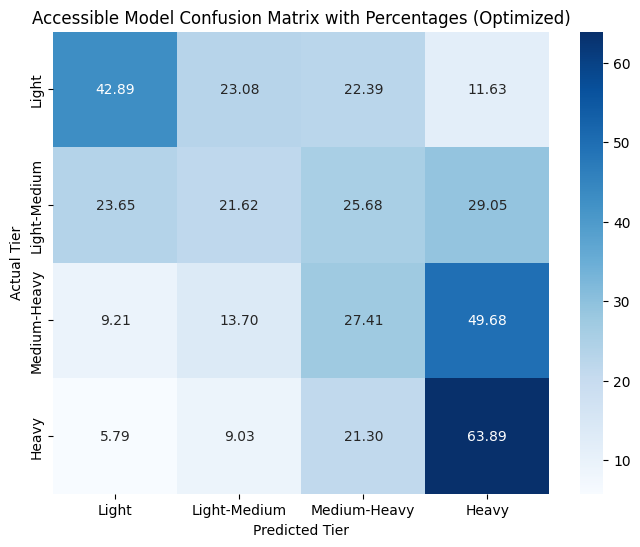


Inaccessible Model Tier Confusion Matrix (Optimized):
Predicted         Light  Light-Medium  Medium-Heavy      Heavy
Actual                                                        
Light         14.111922     55.231144     21.654501   9.002433
Light-Medium   1.318267     45.574388     36.911488  16.195857
Medium-Heavy   1.139601     27.920228     41.025641  29.914530
Heavy          0.607903     12.765957     31.914894  54.711246


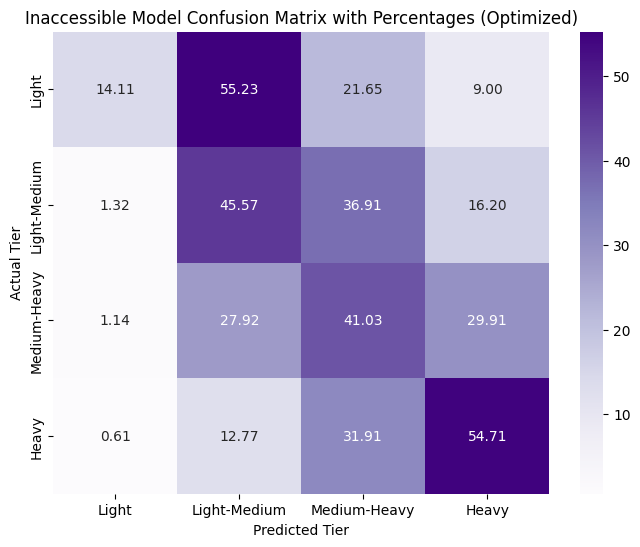

In [62]:
# Ensure predictions and actual values align
def validate_index_alignment(actual, predicted):
    """Validate that actual and predicted indices are perfectly aligned."""
    assert actual.index.equals(predicted.index), "Mismatch between actuals and predictions index!"

# Combine and validate accessible and inaccessible spans
print("\nCombining Test Data Predictions and Actuals (Fixed Index)...")

# Predict on Test data (ensure predictions retain indices)
access_preds_opt = pd.Series(accessible_model.predict(X_test_access), index=X_test_access.index)
inaccess_preds_opt = pd.Series(inaccessible_model.predict(X_test_inaccess), index=X_test_inaccess.index)

# Combine predictions and actuals for overall evaluation
combined_preds_opt = pd.concat([access_preds_opt, inaccess_preds_opt]).sort_index()
combined_y_test = pd.concat([y_test_access, y_test_inaccess]).sort_index()

# Validate index alignment
validate_index_alignment(combined_y_test, combined_preds_opt)

# Calculate combined metrics
mae_combined_opt = mean_absolute_error(combined_y_test, combined_preds_opt)
print("\nMAE for combined model (optimized):", mae_combined_opt)

mae_access_opt = mean_absolute_error(y_test_access, access_preds_opt)
mae_inaccess_opt = mean_absolute_error(y_test_inaccess, inaccess_preds_opt)
print("MAE for accessible model (optimized):", mae_access_opt)
print("MAE for inaccessible model (optimized):", mae_inaccess_opt)

# ------------------------------------------------------------
# Confusion Matrix and Heatmap Visualization
# ------------------------------------------------------------

# Accessible model confusion matrix
tier_actual_access = pd.cut(
    y_test_access.to_numpy(),
    bins=[-np.inf, *access_thres, np.inf],
    labels=tier_labels
)

tier_predicted_access = pd.cut(
    access_preds_opt,
    bins=[-np.inf, *access_thres, np.inf],
    labels=tier_labels
)

print("\nAccessible Model Tier Confusion Matrix (Optimized):")
cm_access = pd.crosstab(tier_actual_access, tier_predicted_access, rownames=["Actual"], colnames=["Predicted"])

cm_access_percentage = cm_access.div(cm_access.sum(axis=1), axis=0) * 100
print(cm_access_percentage)

# Plot accessible confusion matrix heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm_access_percentage, annot=True, fmt=".2f", cmap="Blues")
plt.title("Accessible Model Confusion Matrix with Percentages (Optimized)")
plt.xlabel("Predicted Tier")
plt.ylabel("Actual Tier")
plt.show()

# Inaccessible model confusion matrix
tier_actual_inaccess = pd.cut(
    y_test_inaccess.to_numpy(),
    bins=[-np.inf, *inacces_thres, np.inf],
    labels=tier_labels
)

tier_predicted_inaccess = pd.cut(
    inaccess_preds_opt,
    bins=[-np.inf, *inacces_thres, np.inf],
    labels=tier_labels
)

print("\nInaccessible Model Tier Confusion Matrix (Optimized):")
cm_inaccess = pd.crosstab(tier_actual_inaccess, tier_predicted_inaccess, rownames=["Actual"], colnames=["Predicted"])

cm_inaccess_percentage = cm_inaccess.div(cm_inaccess.sum(axis=1), axis=0) * 100
print(cm_inaccess_percentage)

# Plot inaccessible confusion matrix heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm_inaccess_percentage, annot=True, fmt=".2f", cmap="Purples")
plt.title("Inaccessible Model Confusion Matrix with Percentages (Optimized)")
plt.xlabel("Predicted Tier")
plt.ylabel("Actual Tier")
plt.show()

## 7. Holdout & Evaluation Results

Holdout is prepared for both models, then scored once — behind the
`READY_FOR_FINAL_HOLDOUT_SIGNOFF` gate — for baseline vs. challenger.


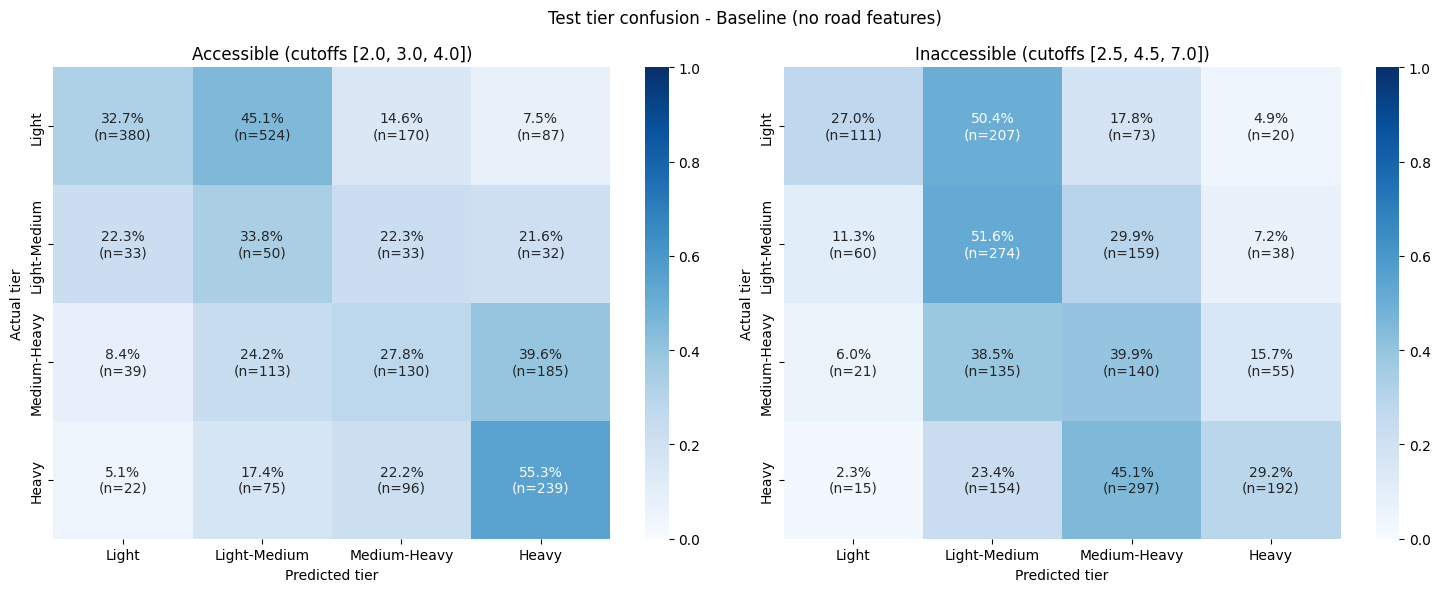

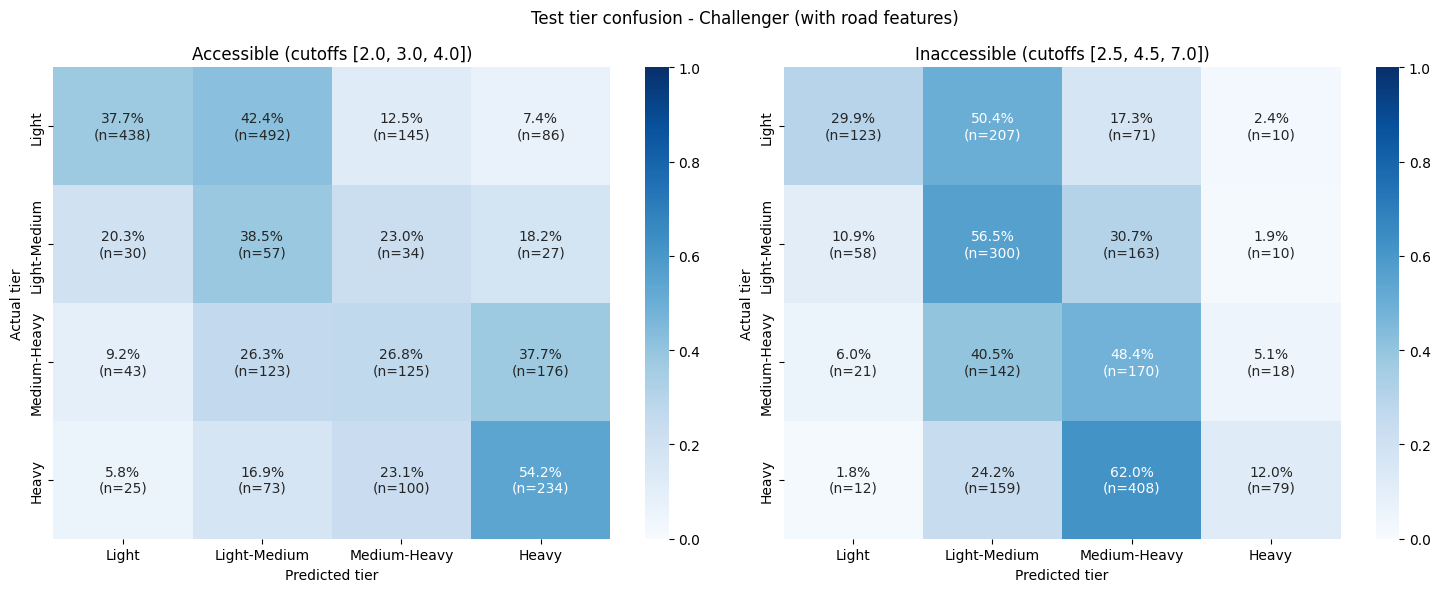

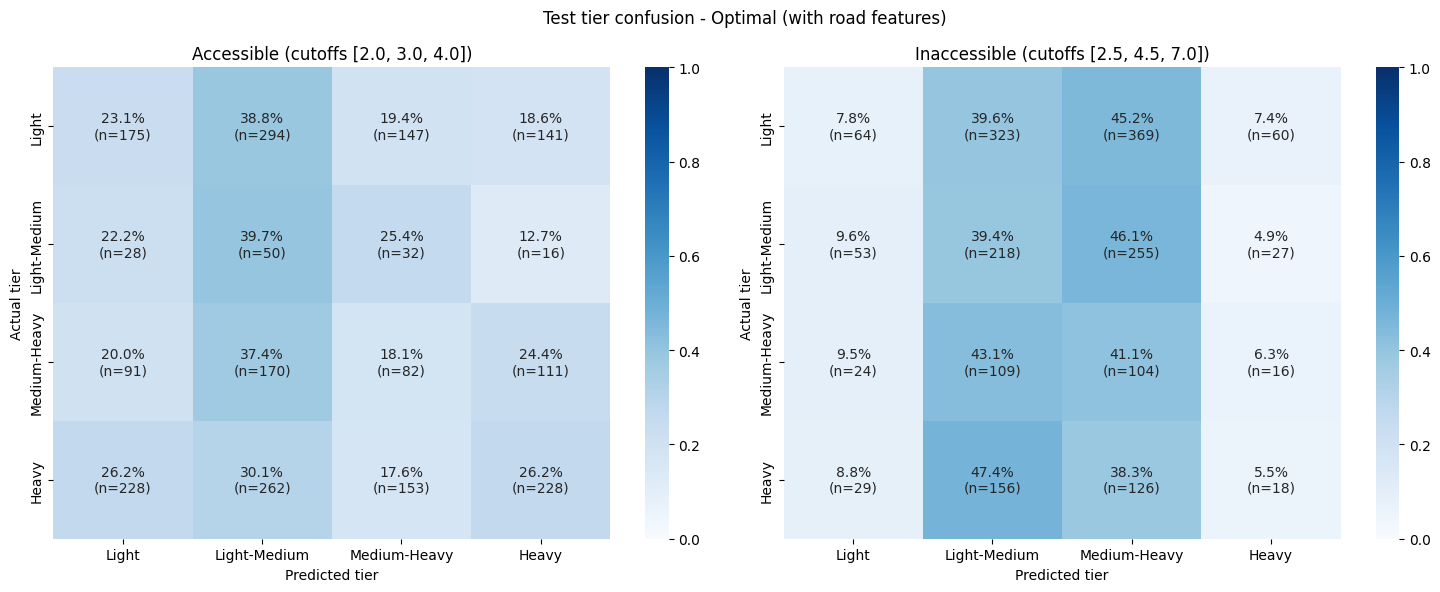

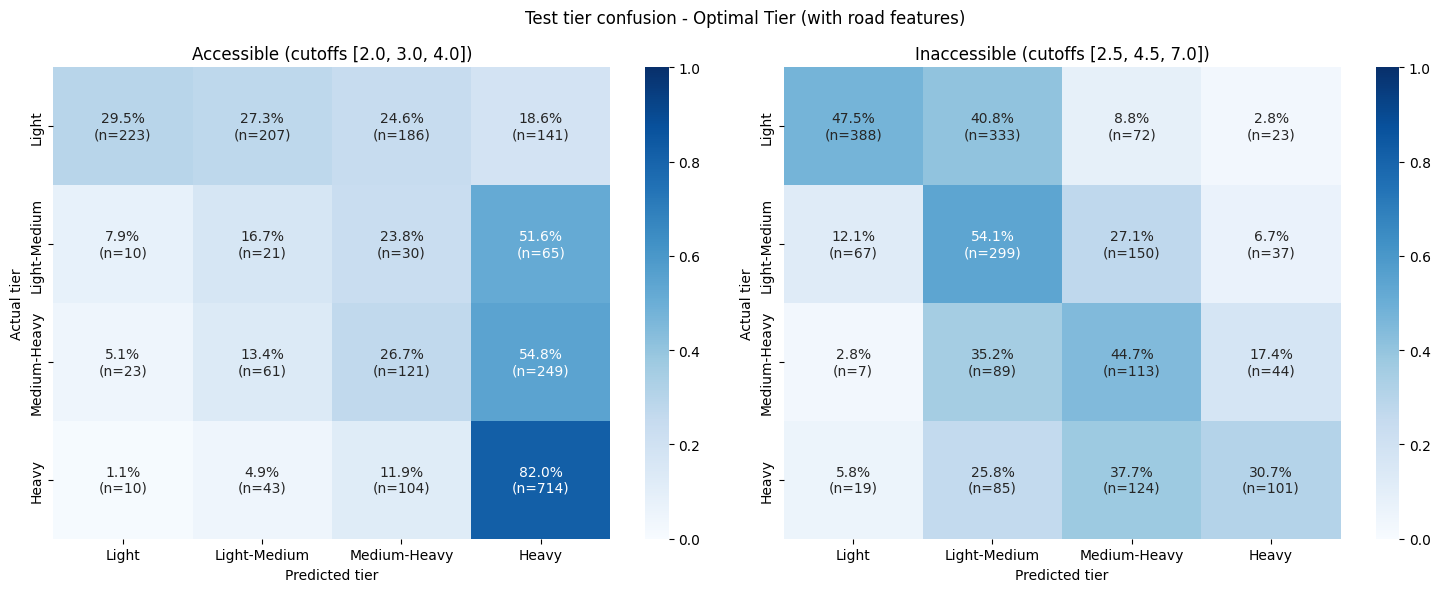

TEST TIER ACCURACY BY MODEL AND ACCESSIBILITY


,Model,Split,Segment,Cutoffs,Count,Accuracy,Macro_F1
0,Baseline (no road features),Test,Accessible,"[2.0, 3.0, 4.0]",2208,0.3619,0.3388
1,Baseline (no road features),Test,Inaccessible,"[2.5, 4.5, 7.0]",1951,0.3675,0.3634
2,Challenger (with road features),Test,Accessible,"[2.0, 3.0, 4.0]",2208,0.3868,0.3552
3,Challenger (with road features),Test,Inaccessible,"[2.5, 4.5, 7.0]",1951,0.3444,0.3345
4,Optimal (with road features),Test,Accessible,"[2.0, 3.0, 4.0]",2208,0.2423,0.2268
5,Optimal (with road features),Test,Inaccessible,"[2.5, 4.5, 7.0]",1951,0.2071,0.1796
6,Optimal Tier (with road features),Test,Accessible,"[2.0, 3.0, 4.0]",2208,0.4887,0.3745
7,Optimal Tier (with road features),Test,Inaccessible,"[2.5, 4.5, 7.0]",1951,0.4618,0.4335


In [63]:
# Workload-tier utilities + TEST confusion matrices for both models.
#
# Accessible and inaccessible spans are tiered on different hour cutoffs
# (access_thres vs. inacces_thres), so every model gets two confusion
# matrices - one per accessibility regime - with four tiers each.

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

TIER_LABELS = list(CONFIG["tier_labels"])
N_TIERS = len(TIER_LABELS)

ACCESS_TIER_THRESHOLDS = list(access_thres)
INACCESS_TIER_THRESHOLDS = list(inacces_thres)

TIER_SEGMENTS = [
    ("Accessible", 0, ACCESS_TIER_THRESHOLDS),
    ("Inaccessible", 1, INACCESS_TIER_THRESHOLDS),
]


def build_tier_bins(thresholds, n_tiers=N_TIERS):
    """Interior cut points are the first n_tiers-1 thresholds; both tails stay open."""
    cuts = sorted(float(t) for t in thresholds)[: n_tiers - 1]

    if len(cuts) != n_tiers - 1:
        raise ValueError(
            f"Need at least {n_tiers - 1} thresholds to build {n_tiers} tiers, "
            f"got {len(thresholds)}."
        )

    return [-np.inf, *cuts, np.inf]


def assign_tiers(values, thresholds, index=None):
    return pd.cut(
        pd.Series(np.asarray(values, dtype=float), index=index),
        bins=build_tier_bins(thresholds),
        labels=TIER_LABELS,
    )


def plot_tier_confusion(ax, actual_tiers, predicted_tiers, title):
    cm = confusion_matrix(actual_tiers, predicted_tiers, labels=TIER_LABELS)
    row_totals = cm.sum(axis=1, keepdims=True)

    cm_pct = np.divide(
        cm,
        row_totals,
        out=np.zeros_like(cm, dtype=float),
        where=row_totals != 0,
    )

    annotations = np.empty_like(cm, dtype=object)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            annotations[i, j] = f"{cm_pct[i, j]:.1%}\n(n={cm[i, j]})"

    sns.heatmap(
        cm_pct,
        annot=annotations,
        fmt="",
        cmap="Blues",
        vmin=0,
        vmax=1,
        xticklabels=TIER_LABELS,
        yticklabels=TIER_LABELS,
        cbar=True,
        ax=ax,
    )
    ax.set_xlabel("Predicted tier")
    ax.set_ylabel("Actual tier")
    ax.set_title(title)


def tier_confusion_by_accessibility(model_name, actual, predicted, index, split_name):
    """Two four-tier confusion matrices per model: accessible and inaccessible spans."""
    flags = (
        pd.to_numeric(df.loc[index, "inaccessible"], errors="coerce")
        .fillna(0)
        .astype(int)
        .clip(0, 1)
    )

    scored = pd.DataFrame(
        {
            "actual": np.asarray(actual, dtype=float),
            "predicted": np.asarray(predicted, dtype=float),
            "inaccessible": flags.to_numpy(),
        },
        index=index,
    )

    fig, axes = plt.subplots(1, len(TIER_SEGMENTS), figsize=(15, 6))
    summary_rows = []

    for ax, (segment_name, flag_value, thresholds) in zip(axes, TIER_SEGMENTS):
        subset = scored.loc[scored["inaccessible"].eq(flag_value)]

        if subset.empty:
            ax.set_visible(False)
            continue

        actual_tiers = assign_tiers(subset["actual"], thresholds, subset.index)
        predicted_tiers = assign_tiers(subset["predicted"], thresholds, subset.index)

        plot_tier_confusion(
            ax,
            actual_tiers,
            predicted_tiers,
            f"{segment_name} (cutoffs {build_tier_bins(thresholds)[1:-1]})",
        )

        summary_rows.append(
            {
                "Model": model_name,
                "Split": split_name,
                "Segment": segment_name,
                "Cutoffs": build_tier_bins(thresholds)[1:-1],
                "Count": len(subset),
                "Accuracy": accuracy_score(actual_tiers, predicted_tiers),
                "Macro_F1": f1_score(actual_tiers, predicted_tiers, average="macro"),
            }
        )

    fig.suptitle(f"{split_name} tier confusion - {model_name}")
    plt.tight_layout()
    plt.show()

    return pd.DataFrame(summary_rows)


test_tier_summary = pd.concat(
    [
        tier_confusion_by_accessibility(
            "Baseline (no road features)",
            actual_test,
            baseline_test_predictions,
            X_test_red.index,
            "Test",
        ),
        tier_confusion_by_accessibility(
            "Challenger (with road features)",
            actual_test,
            road_test_predictions,
            X_test_red_road.index,
            "Test",
        ),
        tier_confusion_by_accessibility(
            "Optimal (with road features)",
            combined_y_test,
            opt_road_test_predictions_combined,
            X_test_combined.index,
            "Test",
        ),
        tier_confusion_by_accessibility(
            "Optimal Tier (with road features)",
            combined_y_test,
            combined_preds_opt,
            X_test_combined.index,
            "Test",
        ),
    ],
    ignore_index=True,
)

print("TEST TIER ACCURACY BY MODEL AND ACCESSIBILITY")
display(test_tier_summary.round(4))


In [64]:
# Prepare holdout for both model pairs.
#
# The baseline pair scores X_holdout_red as-is. The challenger pair needs the same
# road-feature join used for train/test/validation, reusing the train-fit categorical
# vocabulary and numeric medians (no refitting on holdout, so no leakage).
# This cell only prepares data - nothing is scored here, so it is safe to re-run.

road_holdout = lookup_road_features(X_holdout_red, "holdout")

for column in categorical_road_features:
    allowed_values = set(road_train[column].astype(str).unique())
    clean_values = road_holdout[column].astype("string").fillna("Unknown").astype(str)
    road_holdout[column] = np.where(
        clean_values.isin(allowed_values), clean_values, "Other"
    ).astype(str)

road_holdout[numeric_road_model_features] = (
    road_holdout[numeric_road_model_features]
    .apply(pd.to_numeric, errors="coerce")
    .fillna(numeric_imputation)
    .astype(float)
)

X_holdout_red_road = build_road_matrix(X_holdout_red, road_holdout, "holdout").reindex(
    columns=expected_road_columns
)

y_holdout_aligned = align_target_to_features(y_holdout, X_holdout_red, "y_holdout")

holdout_flags = get_accessibility_flags(X_holdout_red.index)

print(
    f"Holdout ready: {len(X_holdout_red):,} spans "
    f"({int(holdout_flags.eq(0).sum()):,} accessible / "
    f"{int(holdout_flags.eq(1).sum()):,} inaccessible) | "
    f"baseline features: {len(baseline_feature_cols)} | "
    f"challenger features: {X_holdout_red_road.shape[1]}"
)

print(
    f"Holdout road-source missing rate: "
    f"{road_holdout['road_feature_source_missing'].mean():.2%}"
)


# Sign-off gate
#
# The next cell is the first and only place holdout is actually scored. Review
# everything upstream first, then flip this flag and re-run this cell.

READY_FOR_FINAL_HOLDOUT_SIGNOFF = False  # <-- set True only when ready to score holdout

if READY_FOR_FINAL_HOLDOUT_SIGNOFF:
    print("READY_FOR_FINAL_HOLDOUT_SIGNOFF is True - the holdout scoring cell will run.")
else:
    print("READY_FOR_FINAL_HOLDOUT_SIGNOFF is False - the holdout scoring cell will refuse")
    print("to run. Set it to True in this cell and re-run when ready.")


Holdout ready: 4,671 spans (2,913 accessible / 1,758 inaccessible) | baseline features: 61 | challenger features: 124
Holdout road-source missing rate: 0.00%
READY_FOR_FINAL_HOLDOUT_SIGNOFF is False - the holdout scoring cell will refuse
to run. Set it to True in this cell and re-run when ready.


import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, r2_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Function to calculate MAE and R²
def calculate_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return mae, r2

# Function to plot confusion matrix with percentages and counts
def plot_tier_confusion_with_details(actual_tiers, predicted_tiers, thresholds, title):
    cm = confusion_matrix(actual_tiers, predicted_tiers, labels=TIER_LABELS)
    row_totals = cm.sum(axis=1, keepdims=True)

    # Calculate percentage confusion matrix
    cm_pct = np.divide(
        cm,
        row_totals,
        out=np.zeros_like(cm, dtype=float),
        where=row_totals != 0,
    ) * 100

    # Annotate with percentages and counts
    annotations = np.empty_like(cm, dtype=object)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            annotations[i, j] = f"{cm_pct[i, j]:.1f}%\n(n={cm[i, j]})"

    # Plot heatmap
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_pct, annot=annotations, fmt="", cmap="Blues", vmin=0, vmax=100, xticklabels=TIER_LABELS, yticklabels=TIER_LABELS)
    plt.title(f"{title}\nCutoffs {thresholds}")
    plt.xlabel("Predicted Tier")
    plt.ylabel("Actual Tier")
    plt.tight_layout()
    plt.show()

# Preparing holdout with optimal models
print("\nPreparing Holdout with optimal models...")

# Accessibility flags
holdout_flags = get_accessibility_flags(X_holdout_red_road.index)

# Predict with optimal models
holdout_access_preds_opt = pd.Series(accessible_model.predict(X_holdout_red_road[holdout_flags == 0]), index=X_holdout_red_road[holdout_flags == 0].index)
holdout_inaccess_preds_opt = pd.Series(inaccessible_model.predict(X_holdout_red_road[holdout_flags == 1]), index=X_holdout_red_road[holdout_flags == 1].index)

# Combine predictions and actuals
holdout_predictions_combined_opt = pd.concat([holdout_access_preds_opt, holdout_inaccess_preds_opt]).sort_index()
actual_holdout_combined = pd.concat([y_holdout_aligned[holdout_flags == 0], y_holdout_aligned[holdout_flags == 1]]).sort_index()

# MAE and R² calculations for individual models
mae_access_holdout, r2_access_holdout = calculate_metrics(y_holdout_aligned[holdout_flags == 0], holdout_access_preds_opt)
mae_inaccess_holdout, r2_inaccess_holdout = calculate_metrics(y_holdout_aligned[holdout_flags == 1], holdout_inaccess_preds_opt)
mae_combined_holdout, r2_combined_holdout = calculate_metrics(actual_holdout_combined, holdout_predictions_combined_opt)

print(f"Accessible Holdout MAE: {mae_access_holdout:.4f}, R²: {r2_access_holdout:.4f}")
print(f"Inaccessible Holdout MAE: {mae_inaccess_holdout:.4f}, R²: {r2_inaccess_holdout:.4f}")
print(f"Combined Holdout MAE: {mae_combined_holdout:.4f}, R²: {r2_combined_holdout:.4f}")

# ------------------------------------------------------------
# Confusion Matrix Visualization
# ------------------------------------------------------------
print("\nEvaluating tier accuracy for optimal models...")

# Accessible model confusion matrix
tier_actual_access_holdout = pd.cut(
    y_holdout_aligned[holdout_flags == 0],
    bins=[-np.inf, *ACCESS_TIER_THRESHOLDS, np.inf],
    labels=TIER_LABELS
)
tier_predicted_access_holdout = pd.cut(
    holdout_access_preds_opt,
    bins=[-np.inf, *ACCESS_TIER_THRESHOLDS, np.inf],
    labels=TIER_LABELS
)

print("\nAccessible Model Tier Confusion Matrix (Optimized):")
plot_tier_confusion_with_details(
    tier_actual_access_holdout,
    tier_predicted_access_holdout,
    ACCESS_TIER_THRESHOLDS,
    "Accessible (Cutoffs)"
)

from sklearn.metrics import accuracy_score

# Calculate span-level accuracy (Accessible spans)
accuracy_access_holdout = accuracy_score(tier_actual_access_holdout, tier_predicted_access_holdout)
print(f"Accessible Model Tier Assignment Accuracy (Holdout): {accuracy_access_holdout:.4%}")


# Inaccessible model confusion matrix
tier_actual_inaccess_holdout = pd.cut(
    y_holdout_aligned[holdout_flags == 1],
    bins=[-np.inf, *INACCESS_TIER_THRESHOLDS, np.inf],
    labels=TIER_LABELS
)
tier_predicted_inaccess_holdout = pd.cut(
    holdout_inaccess_preds_opt,
    bins=[-np.inf, *INACCESS_TIER_THRESHOLDS, np.inf],
    labels=TIER_LABELS
)

print("\nInaccessible Model Tier Confusion Matrix (Optimized):")
plot_tier_confusion_with_details(
    tier_actual_inaccess_holdout,
    tier_predicted_inaccess_holdout,
    INACCESS_TIER_THRESHOLDS,
    "Inaccessible (Cutoffs)"
)

# Calculate span-level accuracy (Inaccessible spans)
accuracy_inaccess_holdout = accuracy_score(tier_actual_inaccess_holdout, tier_predicted_inaccess_holdout)
print(f"Inaccessible Model Tier Assignment Accuracy (Holdout): {accuracy_inaccess_holdout:.4%}")

from sklearn.metrics import classification_report

# Accessible spans classification report
print("\nAccessible Model Classification Report:")
print(classification_report(tier_actual_access_holdout, tier_predicted_access_holdout))

# Inaccessible spans classification report
print("\nInaccessible Model Classification Report:")
print(classification_report(tier_actual_inaccess_holdout, tier_predicted_inaccess_holdout))

# ------------------------------------------------------------
# Feeder-Level Evaluation
# ------------------------------------------------------------
print("\nHoldout Feeder-Level Analysis...")

feeder_combined = df.loc[X_holdout_red.index, "feeder"]

# Ensure alignment for feeder evaluation
feeder_frame = pd.DataFrame({
    "feeder": feeder_combined,
    "actual": actual_holdout_combined,
    "Optimal": holdout_predictions_combined_opt
}).sort_index()

# Aggregate by feeder
feeder_totals = feeder_frame.groupby("feeder").sum().reset_index()
feeder_totals["n_spans"] = feeder_frame.groupby("feeder").size().to_numpy()

# Feeder-Level Metrics
actual_total = feeder_totals["actual"]
predicted_total = feeder_totals["Optimal"]
mae_feeder = np.mean(np.abs(predicted_total - actual_total))
r2_feeder = r2_score(actual_total, predicted_total)

print(f"\nFeeder-Level MAE: {mae_feeder:.4f}, R²: {r2_feeder:.4f}")

# Plot feeder-level scatterplot with R²
plt.figure(figsize=(8, 6))
plt.scatter(feeder_totals["actual"], feeder_totals["Optimal"], alpha=0.7, edgecolor='k')
plt.plot(
    [feeder_totals["actual"].min(), feeder_totals["actual"].max()],
    [feeder_totals["actual"].min(), feeder_totals["actual"].max()],
    color='red', linestyle='--', label="Perfect Prediction"
)
plt.xlabel("Actual Total")
plt.ylabel("Predicted Total (Optimal)")
plt.title(f"Feeder-Level Holdout Comparison")
# Annotate plot with R² value
plt.text(
    0.8, 0.45, f"R² = {r2_feeder:.2f}",
    horizontalalignment='left',
    verticalalignment='center',
    transform=plt.gca().transAxes,
    fontsize=12,
    color='blue'
)
plt.gca().set_aspect("equal", adjustable="box")
plt.legend()
plt.tight_layout()
plt.show()

def plot_feature_importance(model, feature_names, title="Feature Importance", top_n=20):
    """
    Plot feature importance for a given model on holdout data.
    Args:
        model (CatBoostRegressor): Fitted CatBoost model
        feature_names (list): List of feature names corresponding to model input
        title (str): Title of the plot
        top_n (int): Number of top features to display (default: 20)
    """
    # Extract feature importance from the model
    importance = model.get_feature_importance()
    
    # Combine feature names and importance into a DataFrame
    importance_df = pd.DataFrame({
        "feature": feature_names,
        "importance": importance
    }).sort_values(by="importance", ascending=False).head(top_n)

    # Plot the feature importance
    plt.figure(figsize=(10, 6))
    plt.barh(importance_df["feature"][::-1], importance_df["importance"][::-1], color='steelblue')
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.title(f"{title} - CatBoost Model (Top {top_n})")
    plt.tight_layout()
    plt.show()

# Accessibility model feature importance
print("\nAccessible Model Feature Importance:")
plot_feature_importance(
    accessible_model,
    feature_names=X_holdout_red_road.columns.to_list(),
    title="Feature Importance (Accessible Model)"
)

# Inaccessibility model feature importance
print("\nInaccessible Model Feature Importance:")
plot_feature_importance(
    inaccessible_model,
    feature_names=X_holdout_red_road.columns.to_list(),
    title="Feature Importance (Inaccessible Model)"
)

In [65]:
# HOLDOUT SIGN-OFF: baseline pair (no road features) vs. challenger pair (with road features)

if not READY_FOR_FINAL_HOLDOUT_SIGNOFF:
    raise RuntimeError(
        "READY_FOR_FINAL_HOLDOUT_SIGNOFF is False. This is the final holdout "
        "sign-off check - set the flag to True in the preparation cell above, "
        "re-run that cell, then re-run this cell."
    )

print("=" * 70)
print("HOLDOUT IS BEING SCORED IN THIS CELL. Record this run.")
print("=" * 70)

baseline_holdout_preds = predict_accessibility_split(
    baseline_models, X_holdout_red[baseline_feature_cols]
)
road_holdout_preds = predict_accessibility_split(road_models, X_holdout_red_road)

actual_holdout = y_holdout_aligned.to_numpy()

holdout_models = {
    "Baseline (no road features)": baseline_holdout_preds,
    "Challenger (with road features)": road_holdout_preds,
}


# ------------------------------------------------------------
# MAE / R2 per accessibility model and combined
# ------------------------------------------------------------

holdout_accessibility_scores = pd.concat(
    [
        score_by_accessibility(
            model_name, actual_holdout, predictions, X_holdout_red.index, "Holdout"
        )
        for model_name, predictions in holdout_models.items()
    ],
    ignore_index=True,
)

print("\nHOLDOUT MAE / R2 BY ACCESSIBILITY MODEL")

for segment_name in SCORE_SEGMENTS:
    segment_scores = holdout_accessibility_scores.loc[
        holdout_accessibility_scores["Segment"].eq(segment_name)
    ]

    if segment_scores.empty:
        continue

    print(f"\n{segment_name} model:")
    for row in segment_scores.itertuples():
        print(f"  {row.Model:<34} n={row.Count:>6,}  MAE={row.MAE:.4f}  R2={row.R2:.4f}")

display(
    holdout_accessibility_scores.pivot(
        index="Segment", columns="Model", values=["MAE", "R2"]
    ).round(4)
)

holdout_comparison = pd.DataFrame(
    [
        calculate_metrics(model_name, actual_holdout, predictions)
        for model_name, predictions in holdout_models.items()
    ]
)

print("\n=== HOLDOUT OVERALL COMPARISON ===")
display(holdout_comparison.round(4))


# ------------------------------------------------------------
# Four-tier confusion matrices, one pair per model
# ------------------------------------------------------------

holdout_tier_summary = pd.concat(
    [
        tier_confusion_by_accessibility(
            model_name,
            actual_holdout,
            predictions,
            X_holdout_red.index,
            "Holdout",
        )
        for model_name, predictions in holdout_models.items()
    ],
    ignore_index=True,
)

print("HOLDOUT TIER ACCURACY BY MODEL AND ACCESSIBILITY")
display(holdout_tier_summary.round(4))


# ------------------------------------------------------------
# Challenger feature importance (top 20 per regime model)
# ------------------------------------------------------------

fig, axes = plt.subplots(1, len(road_models), figsize=(16, 6))

for ax, (segment_name, model) in zip(axes, road_models.items()):
    segment_importance = (
        pd.DataFrame({
            "Feature": X_tune_road.columns,
            "Importance": model.get_feature_importance(),
        })
        .sort_values("Importance", ascending=False)
        .head(20)
    )

    ax.barh(segment_importance["Feature"][::-1], segment_importance["Importance"][::-1])
    ax.set_xlabel("Importance")
    ax.set_title(f"{segment_name} challenger model (top 20)")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Errors by impactful_issues
# ------------------------------------------------------------

holdout_issue_series = df.loc[X_holdout_red.index, "impactful_issues"]
holdout_issue_tables = {}

for model_name, predictions in holdout_models.items():
    issue_eval = pd.DataFrame(
        {
            "actual": actual_holdout,
            "predicted": predictions,
            "impactful_issues": holdout_issue_series.to_numpy(),
        }
    )
    issue_eval["abs_error"] = (issue_eval["predicted"] - issue_eval["actual"]).abs()

    issue_table = (
        issue_eval.groupby("impactful_issues", dropna=False)
        .agg(
            n=("actual", "size"),
            MAE=("abs_error", "mean"),
            Actual_Mean=("actual", "mean"),
            Predicted_Mean=("predicted", "mean"),
        )
        .sort_values("MAE", ascending=False)
    )

    issue_table["perc_diff"] = (
        (issue_table["Predicted_Mean"] - issue_table["Actual_Mean"])
        / issue_table["Actual_Mean"].replace(0, np.nan)
        * 100
    )

    holdout_issue_tables[model_name] = issue_table

    print(f"Holdout performance by impactful_issues - {model_name}:")
    display(issue_table.round(3))

# Used by the per-issue feature-importance cell below.
holdout_by_issue = holdout_issue_tables["Challenger (with road features)"]


# ------------------------------------------------------------
# Feeder-level totals
# ------------------------------------------------------------

feeder_frame = pd.DataFrame(
    {
        "feeder": df.loc[X_holdout_red.index, "feeder"].to_numpy(),
        "actual": actual_holdout,
        "Baseline (no road features)": baseline_holdout_preds,
        "Challenger (with road features)": road_holdout_preds,
    }
)

feeder_totals = feeder_frame.groupby("feeder").sum(numeric_only=True).reset_index()
feeder_totals["n_spans"] = feeder_frame.groupby("feeder").size().to_numpy()

fig, axes = plt.subplots(1, len(holdout_models), figsize=(14, 6))
feeder_rows = []

all_values = feeder_totals[["actual", *holdout_models.keys()]].to_numpy()
lims = [all_values.min(), all_values.max()]

for ax, model_name in zip(axes, holdout_models):
    absolute_error = (feeder_totals[model_name] - feeder_totals["actual"]).abs()
    error_pct = absolute_error / feeder_totals["actual"].replace(0, np.nan) * 100
    feeder_r2 = r2_score(feeder_totals["actual"], feeder_totals[model_name])

    feeder_rows.append(
        {
            "Model": model_name,
            "Feeder_Count": len(feeder_totals),
            "Feeder_MAE_Hours": absolute_error.mean(),
            "Median_Abs_Pct_Error": error_pct.median(),
            "Feeder_R2": feeder_r2,
        }
    )

    ax.scatter(
        feeder_totals["actual"],
        feeder_totals[model_name],
        alpha=0.7,
        edgecolor="k",
        linewidth=0.3,
    )
    ax.plot(lims, lims, "r--", linewidth=1, label="Perfect prediction")
    ax.set_xlabel("Actual total manhours (feeder)")
    ax.set_ylabel("Predicted total manhours (feeder)")
    ax.set_title(f"{model_name}\nR2 = {feeder_r2:.3f}")
    ax.legend()
    ax.set_aspect("equal", adjustable="box")

plt.tight_layout()
plt.show()

holdout_feeder_comparison = pd.DataFrame(feeder_rows)

print("HOLDOUT FEEDER-LEVEL COMPARISON")
display(holdout_feeder_comparison.round(4))


RuntimeError: READY_FOR_FINAL_HOLDOUT_SIGNOFF is False. This is the final holdout sign-off check - set the flag to True in the preparation cell above, re-run that cell, then re-run this cell.

In [ ]:
# Save span-level holdout predictions for both models
holdout_predictions = pd.DataFrame(
    {
        "feeder": df.loc[X_holdout_red.index, "feeder"].to_numpy(),
        "bay": df.loc[X_holdout_red.index, "bay"].to_numpy(),
        "inaccessible": df.loc[X_holdout_red.index, "inaccessible"].to_numpy(),
        "actual_manhours": actual_holdout,
        "baseline_pred": baseline_holdout_preds,
        "road_pred": road_holdout_preds,
    },
    index=X_holdout_red.index,
)

holdout_predictions_path = os.path.join(CONFIG["output_dir"], "holdout_predictions.csv")
holdout_predictions.to_csv(holdout_predictions_path, index=True)
print(f"Saved holdout predictions to {holdout_predictions_path}")


In [ ]:
# Top model-important features for the highest-error impactful issues
#
# Issues are ranked by holdout MAE, but the diagnostic models are fit only on
# Train + Validation spans so holdout stays untouched for scoring purposes.

TOP_N_ISSUES = 10
TOP_N_IMPORTANT_FEATURES = 15
MIN_ISSUE_ROWS_FOR_IMPORTANCE = 20

issue_mae_ranking = (
    holdout_by_issue.reset_index()
    .dropna(subset=["impactful_issues"])
    .sort_values("MAE", ascending=False)
)

top_impactful_issues = issue_mae_ranking["impactful_issues"].head(TOP_N_ISSUES).tolist()
issue_series_tune = df.loc[X_tune_road.index, "impactful_issues"]

important_features_by_issue = {}

for issue_value in top_impactful_issues:
    issue_mask = issue_series_tune.eq(issue_value)
    issue_row_count = int(issue_mask.sum())

    if issue_row_count < MIN_ISSUE_ROWS_FOR_IMPORTANCE:
        print(
            f"[{issue_value}] skipped - only {issue_row_count} Train+Validation rows "
            f"(< {MIN_ISSUE_ROWS_FOR_IMPORTANCE})."
        )
        continue

    issue_pool = Pool(
        X_tune_road.loc[issue_mask],
        y_tune.loc[issue_mask],
        cat_features=catboost_road_categorical_cols,
    )

    issue_model = CatBoostRegressor(**road_catboost_params)
    issue_model.fit(issue_pool, verbose=False)

    issue_importance = (
        pd.Series(
            issue_model.get_feature_importance(issue_pool),
            index=X_tune_road.columns,
            name="importance",
        )
        .sort_values(ascending=False)
        .head(TOP_N_IMPORTANT_FEATURES)
        .rename_axis("feature")
        .reset_index()
    )
    issue_importance.insert(0, "impactful_issue", issue_value)
    issue_importance.insert(1, "n_train_valid_spans", issue_row_count)
    important_features_by_issue[issue_value] = issue_importance

    print(
        f"Top {TOP_N_IMPORTANT_FEATURES} model-important features for "
        f"'{issue_value}' ({issue_row_count:,} Train+Validation spans):"
    )
    display(issue_importance.round(3))

if important_features_by_issue:
    top_issue_feature_importance = pd.concat(
        important_features_by_issue.values(), ignore_index=True
    )
else:
    top_issue_feature_importance = pd.DataFrame(
        columns=["impactful_issue", "n_train_valid_spans", "feature", "importance"]
    )
